In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.titlesize"] = 13
sns.set_style("whitegrid")

train_transaction = pd.read_csv("ieee-fraud-detection/train_transaction.csv")
train_identity    = pd.read_csv("ieee-fraud-detection/train_identity.csv")
test_transaction  = pd.read_csv("ieee-fraud-detection/test_transaction.csv")

= train_transaction.merge(train_identity, on="TransactionID", how="left")
test  = test_transaction.copy()

split = train["TransactionDT"].quantile(0.80)
tr  = train[train["TransactionDT"] <= split].copy()
val = train[train["TransactionDT"] >  split].copy()

print(f"train {train.shape}  |  tr {tr.shape}  |  val {val.shape}  |  test {test.shape}")

train (590540, 434)  |  tr (472432, 434)  |  val (118108, 434)  |  test (506691, 393)


## 1. TransactionDT

Raw value is seconds elapsed from an unknown reference point — treat it as relative time.

In [3]:
print("=== TransactionDT stats ===")
print(train["TransactionDT"].describe())
print(f"range: {train['TransactionDT'].max() - train['TransactionDT'].min():,} seconds  = {(train['TransactionDT'].max()-train['TransactionDT'].min())/86400:.1f} days")
print(f"test range:  {test['TransactionDT'].max() - test['TransactionDT'].min():,} seconds  = {(test['TransactionDT'].max()-test['TransactionDT'].min())/86400:.1f} days")
print(f"train max vs test min gap: {test['TransactionDT'].min() - train['TransactionDT'].max():,} seconds")

=== TransactionDT stats ===
count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64
range: 15,724,731 seconds  = 182.0 days
test range:  15,811,121 seconds  = 183.0 days
train max vs test min gap: 2,592,093 seconds


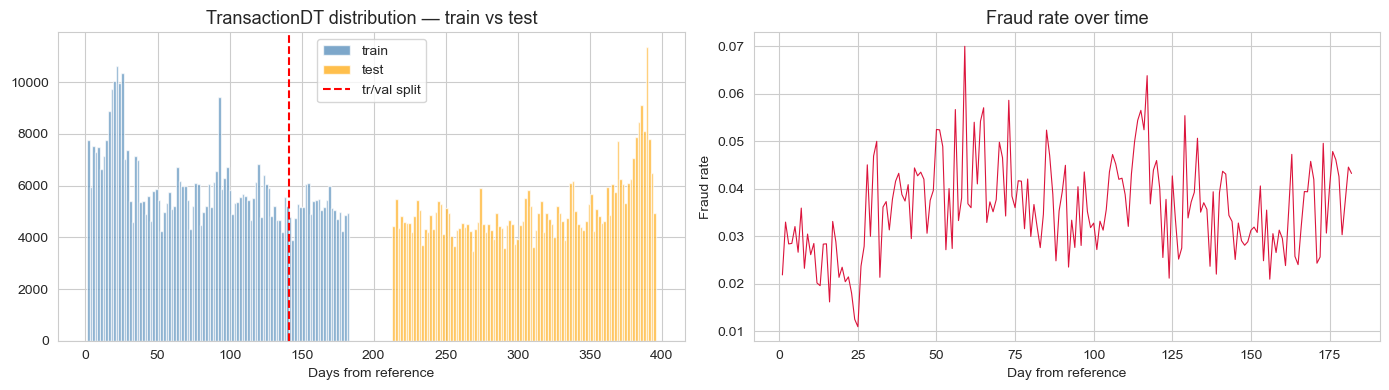

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train["TransactionDT"] / 86400, bins=100, color="steelblue", alpha=0.7, label="train")
axes[0].hist(test["TransactionDT"]  / 86400, bins=100, color="orange",   alpha=0.7, label="test")
axes[0].axvline(split / 86400, color="red", linestyle="--", label="tr/val split")
axes[0].set_xlabel("Days from reference")
axes[0].set_title("TransactionDT distribution — train vs test")
axes[0].legend()

# fraud rate over time (binned by day)
train["day"] = train["TransactionDT"] // 86400
fraud_by_day = train.groupby("day")["isFraud"].mean()
axes[1].plot(fraud_by_day.index, fraud_by_day.values, color="crimson", linewidth=0.8)
axes[1].set_xlabel("Day from reference")
axes[1].set_ylabel("Fraud rate")
axes[1].set_title("Fraud rate over time")

plt.tight_layout()
plt.show()

### 1.1 Cyclic time features

TransactionDT encodes hour-of-day and day-of-week signals. Extract them and encode cyclically so LightGBM sees the periodicity.

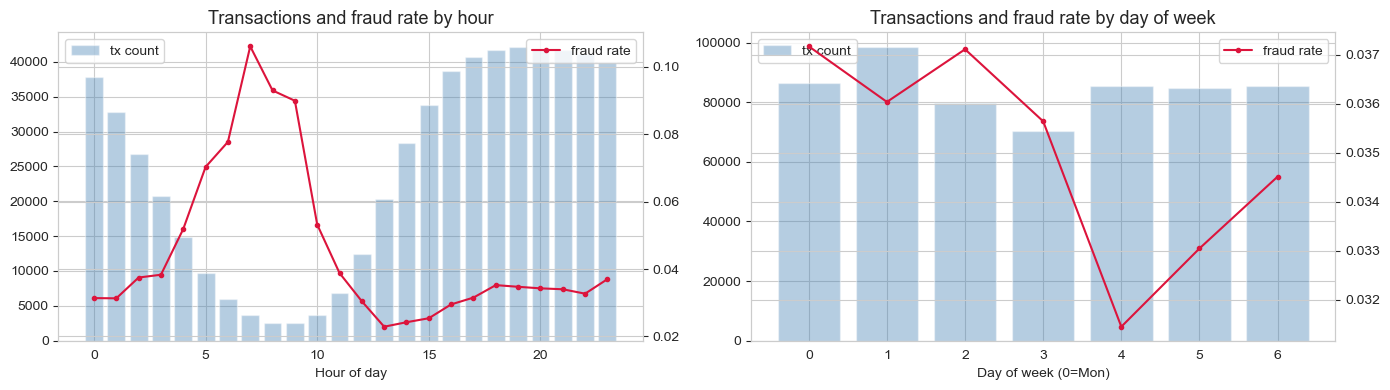

In [5]:
# extract cyclic components
for df in [train, test]:
    df["hour"]       = (df["TransactionDT"] // 3600) % 24
    df["dayofweek"]  = (df["TransactionDT"] // 86400) % 7
    df["day"]        = df["TransactionDT"]  // 86400

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fraud_by_hour = train.groupby("hour")["isFraud"].mean()
count_by_hour = train.groupby("hour")["isFraud"].count()
ax2 = axes[0].twinx()
axes[0].bar(fraud_by_hour.index, count_by_hour.values, color="steelblue", alpha=0.4, label="tx count")
ax2.plot(fraud_by_hour.index, fraud_by_hour.values, color="crimson", marker="o", markersize=3, label="fraud rate")
axes[0].set_xlabel("Hour of day")
axes[0].set_title("Transactions and fraud rate by hour")
axes[0].legend(loc="upper left")
ax2.legend(loc="upper right")

fraud_by_dow = train.groupby("dayofweek")["isFraud"].mean()
count_by_dow = train.groupby("dayofweek")["isFraud"].count()
ax2b = axes[1].twinx()
axes[1].bar(fraud_by_dow.index, count_by_dow.values, color="steelblue", alpha=0.4, label="tx count")
ax2b.plot(fraud_by_dow.index, fraud_by_dow.values, color="crimson", marker="o", markersize=3, label="fraud rate")
axes[1].set_xlabel("Day of week (0=Mon)")
axes[1].set_title("Transactions and fraud rate by day of week")
axes[1].legend(loc="upper left")
ax2b.legend(loc="upper right")

plt.tight_layout()
plt.show()

In [6]:
# sine/cosine encoding for cyclic features
for df in [train, test]:
    df["hour_sin"]      = np.sin(2 * np.pi * df["hour"]      / 24)
    df["hour_cos"]      = np.cos(2 * np.pi * df["hour"]      / 24)
    df["dayofweek_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

print("New cyclic features added:")
print([c for c in train.columns if "sin" in c or "cos" in c])

New cyclic features added:
['hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos']


### 1.2 Train / val / test distribution shift

If the time range of test is beyond train, raw TransactionDT will leak temporal position. Consider normalising or using relative time.

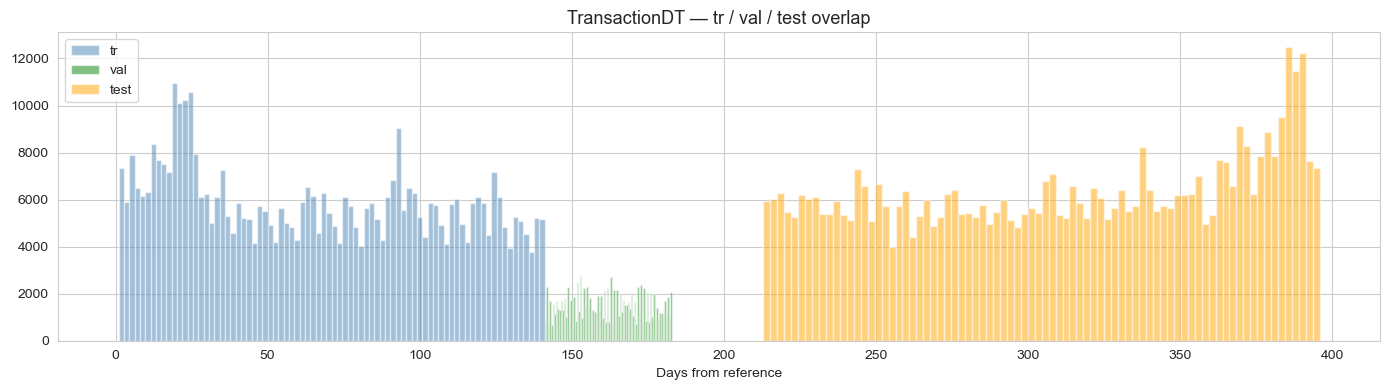

tr   : 1.0 — 141.1 days
val  : 141.1 — 183.0 days
test : 213.0 — 396.0 days


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
for df, label, color in [(tr, "tr", "steelblue"), (val, "val", "green"), (test, "test", "orange")]:
    ax.hist(df["TransactionDT"] / 86400, bins=80, alpha=0.5, label=label, color=color)
ax.set_xlabel("Days from reference")
ax.set_title("TransactionDT — tr / val / test overlap")
ax.legend()
plt.tight_layout()
plt.show()

print(f"tr   : {tr['TransactionDT'].min()/86400:.1f} — {tr['TransactionDT'].max()/86400:.1f} days")
print(f"val  : {val['TransactionDT'].min()/86400:.1f} — {val['TransactionDT'].max()/86400:.1f} days")
print(f"test : {test['TransactionDT'].min()/86400:.1f} — {test['TransactionDT'].max()/86400:.1f} days")

## 2. TransactionAmt

In [9]:
print("=== TransactionAmt stats ===")
print(train["TransactionAmt"].describe(percentiles=[.25,.5,.75,.9,.95,.99]))
print(f"skewness : {train['TransactionAmt'].skew():.2f}")
print(f"kurtosis : {train['TransactionAmt'].kurtosis():.2f}")
print(f"zeros    : {(train['TransactionAmt']==0).sum()}")
print(f"negatives: {(train['TransactionAmt']<0).sum()}")

=== TransactionAmt stats ===
count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
90%         275.293000
95%         445.000000
99%        1104.000000
max       31937.391000
Name: TransactionAmt, dtype: float64
skewness : 14.37
kurtosis : 1123.96
zeros    : 0
negatives: 0


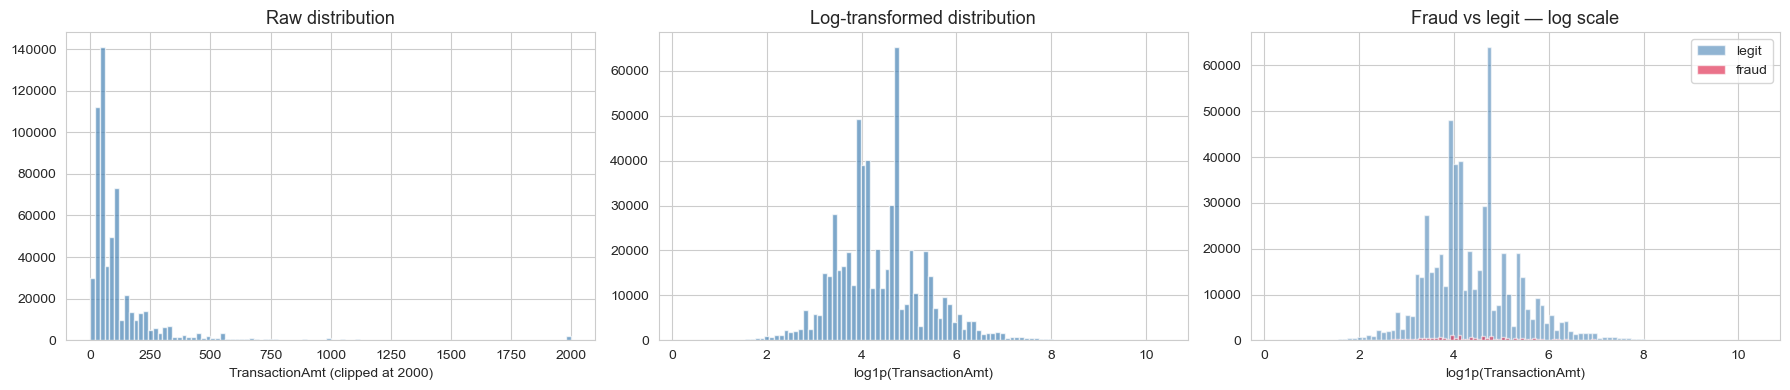

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# raw distribution
axes[0].hist(train["TransactionAmt"].clip(upper=2000), bins=100, color="steelblue", alpha=0.7)
axes[0].set_xlabel("TransactionAmt (clipped at 2000)")
axes[0].set_title("Raw distribution")

# log distribution
log_amt = np.log1p(train["TransactionAmt"])
axes[1].hist(log_amt, bins=100, color="steelblue", alpha=0.7)
axes[1].set_xlabel("log1p(TransactionAmt)")
axes[1].set_title("Log-transformed distribution")

# fraud vs non-fraud
axes[2].hist(np.log1p(train.loc[train["isFraud"]==0, "TransactionAmt"]), bins=100, alpha=0.6, color="steelblue", label="legit")
axes[2].hist(np.log1p(train.loc[train["isFraud"]==1, "TransactionAmt"]), bins=100, alpha=0.6, color="crimson",   label="fraud")
axes[2].set_xlabel("log1p(TransactionAmt)")
axes[2].set_title("Fraud vs legit — log scale")
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.1 Train vs test distribution shift

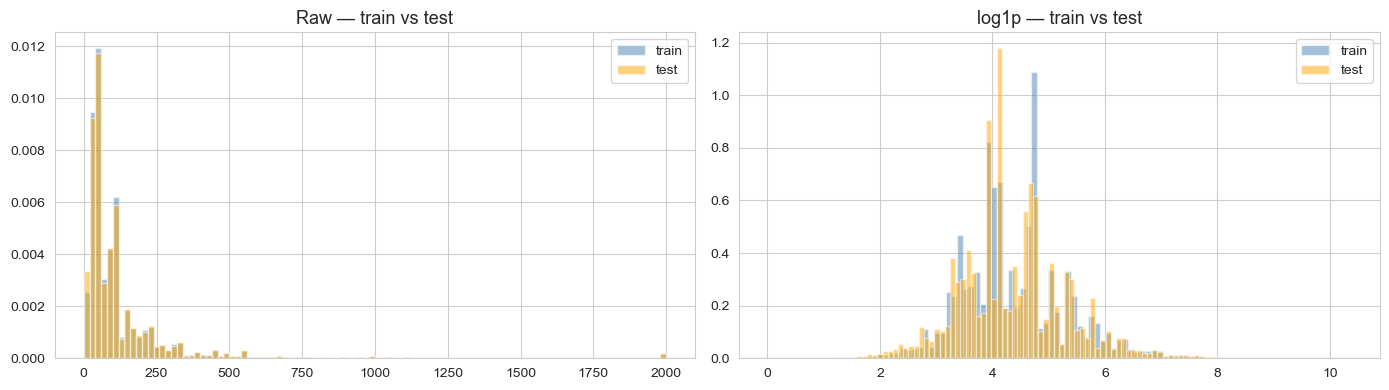

KS statistic: 0.0176  p-value: 6.1578e-74
Significant shift


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for df, label, color in [(train, "train", "steelblue"), (test, "test", "orange")]:
    axes[0].hist(df["TransactionAmt"].clip(upper=2000), bins=100, alpha=0.5, label=label, color=color, density=True)
    axes[1].hist(np.log1p(df["TransactionAmt"]),        bins=100, alpha=0.5, label=label, color=color, density=True)

axes[0].set_title("Raw — train vs test")
axes[1].set_title("log1p — train vs test")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

# KS test
ks_stat, ks_p = stats.ks_2samp(train["TransactionAmt"], test["TransactionAmt"])
print(f"KS statistic: {ks_stat:.4f}  p-value: {ks_p:.4e}")
print("Significant shift" if ks_p < 0.05 else "No significant shift")

### 2.2 Fraud rate by amount bucket

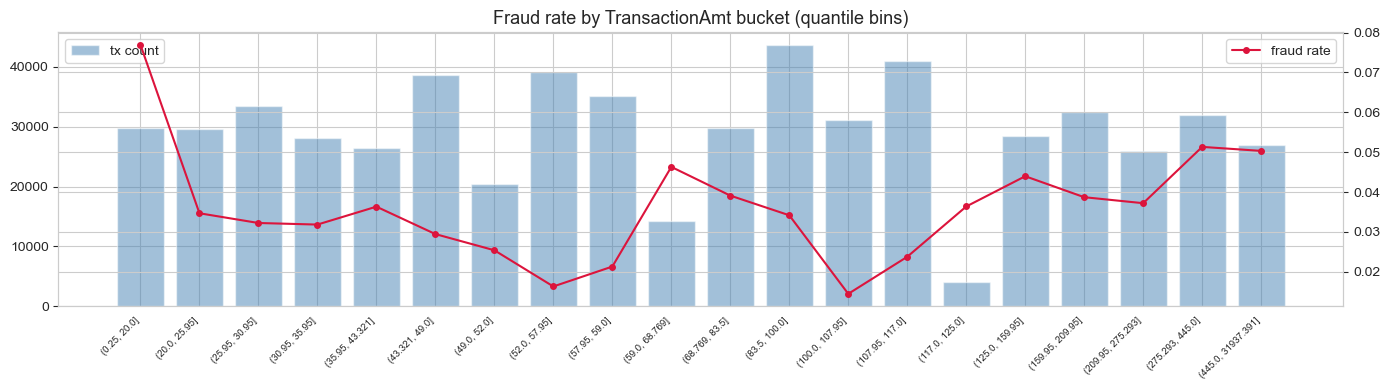

In [12]:
train["amt_bucket"] = pd.qcut(train["TransactionAmt"], q=20, duplicates="drop")
bucket_stats = train.groupby("amt_bucket", observed=True)["isFraud"].agg(["mean", "count"]).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(range(len(bucket_stats)), bucket_stats["count"], color="steelblue", alpha=0.5, label="tx count")
ax2.plot(range(len(bucket_stats)), bucket_stats["mean"],  color="crimson",   marker="o", markersize=4, label="fraud rate")
ax1.set_xticks(range(len(bucket_stats)))
ax1.set_xticklabels([str(b) for b in bucket_stats["amt_bucket"]], rotation=45, ha="right", fontsize=7)
ax1.set_title("Fraud rate by TransactionAmt bucket (quantile bins)")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 2.3 Decimal / cents pattern

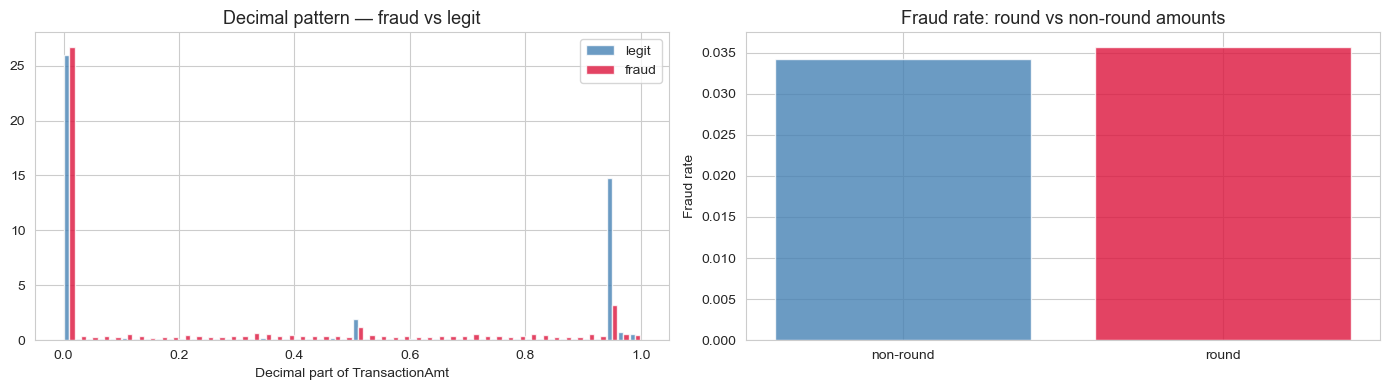

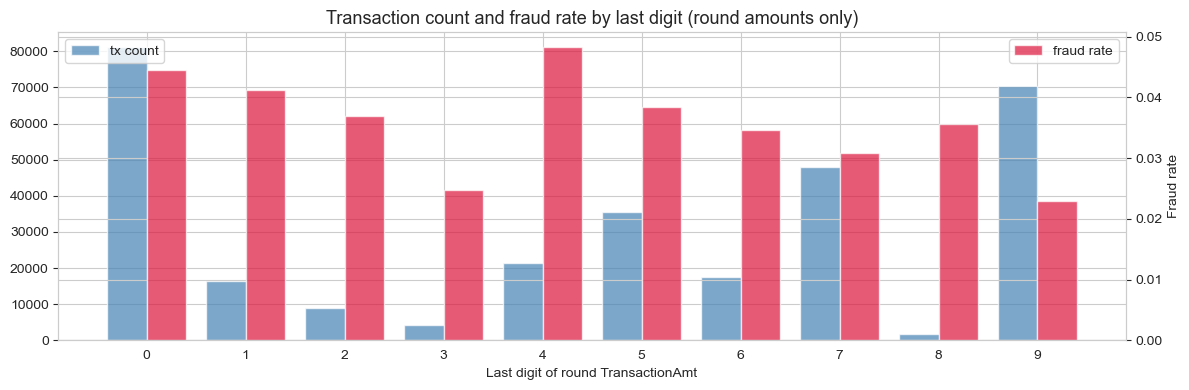

 last_digit  fraud_rate  count
          0    0.044472  81197
          1    0.041218  16328
          2    0.036917   8966
          3    0.024795   4154
          4    0.048311  21486
          5    0.038366  35396
          6    0.034655  17602
          7    0.030933  47845
          8    0.035561   1631
          9    0.023009  70408


In [15]:
# fractional part often signals card-present vs card-not-present
train["amt_decimal"] = train["TransactionAmt"] % 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# side-by-side bars
bins = np.linspace(0, 1, 51)
width = (bins[1] - bins[0]) / 2.2
legit_counts, _ = np.histogram(train.loc[train["isFraud"]==0, "amt_decimal"], bins=bins, density=True)
fraud_counts, _ = np.histogram(train.loc[train["isFraud"]==1, "amt_decimal"], bins=bins, density=True)
centers = (bins[:-1] + bins[1:]) / 2

axes[0].bar(centers - width/2, legit_counts, width=width, color="steelblue", alpha=0.8, label="legit")
axes[0].bar(centers + width/2, fraud_counts, width=width, color="crimson",   alpha=0.8, label="fraud")
axes[0].set_xlabel("Decimal part of TransactionAmt")
axes[0].set_title("Decimal pattern — fraud vs legit")
axes[0].legend()

# round vs non-round fraud rate
round_flag = (train["amt_decimal"] == 0).astype(int)
axes[1].bar(["non-round", "round"],
            [train.loc[round_flag==0, "isFraud"].mean(),
             train.loc[round_flag==1, "isFraud"].mean()],
            color=["steelblue", "crimson"], alpha=0.8)
axes[1].set_ylabel("Fraud rate")
axes[1].set_title("Fraud rate: round vs non-round amounts")

plt.tight_layout()
plt.show()

# last digit analysis — round numbers only
round_tx = train[train["amt_decimal"] == 0].copy()
round_tx["last_digit"] = round_tx["TransactionAmt"].astype(int) % 10

digit_stats = round_tx.groupby("last_digit")["isFraud"].agg(["mean", "count"]).reset_index()
digit_stats.columns = ["last_digit", "fraud_rate", "count"]

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
x = digit_stats["last_digit"]
ax1.bar(x - 0.2, digit_stats["count"],      width=0.4, color="steelblue", alpha=0.7, label="tx count")
ax2.bar(x + 0.2, digit_stats["fraud_rate"],  width=0.4, color="crimson",   alpha=0.7, label="fraud rate")
ax1.set_xlabel("Last digit of round TransactionAmt")
ax1.set_title("Transaction count and fraud rate by last digit (round amounts only)")
ax1.set_xticks(range(10))
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
ax2.set_ylabel("Fraud rate")
plt.tight_layout()
plt.show()

print(digit_stats.to_string(index=False))

## 3. Feature engineering summary

| Feature | Rationale |
|---------|-----------|
| , ,  | Cyclic time signals from TransactionDT |
| ,  | Cyclic encoding so LightGBM sees periodicity |
|  | Reduces right skew; separates fraud/legit clusters better |
|  | Cents pattern differs between fraud and legit |
|  | Round amounts have different fraud rate |

In [ ]:
# apply engineering to tr / val / test
for df in [tr, val, test]:
    df["hour"]         = (df["TransactionDT"] // 3600) % 24
    df["dayofweek"]    = (df["TransactionDT"] // 86400) % 7
    df["day"]          = df["TransactionDT"]  // 86400
    df["hour_sin"]     = np.sin(2 * np.pi * df["hour"]      / 24)
    df["hour_cos"]     = np.cos(2 * np.pi * df["hour"]      / 24)
    df["dayofweek_sin"]= np.sin(2 * np.pi * df["dayofweek"] / 7)
    df["dayofweek_cos"]= np.cos(2 * np.pi * df["dayofweek"] / 7)

    df["log_amt"]      = np.log1p(df["TransactionAmt"])
    df["amt_decimal"]  = (df["TransactionAmt"] % 1).round(2).astype("category")
    df["amt_is_round"] = (df["TransactionAmt"] % 1 == 0).astype(np.int8)
    df["amt_last_digit"] = np.where(
        df["TransactionAmt"] % 1 == 0,
        df["TransactionAmt"].astype(int) % 10,
        -1
    ).astype("category")

num_features = ["hour", "dayofweek", "day",
                "hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos",
                "log_amt", "amt_is_round"]
cat_features = ["amt_decimal", "amt_last_digit"]

print("Numeric features :", num_features)
print("Category features:", cat_features)

## 4. Combined feature — per-card transaction count in last 24h

For each transaction at time *t*, count how many transactions the **same card** made in [t-86400, t). Then analyze whether high/low activity cards have different fraud rates.

In [24]:

time_len = 86400 *2
def card_tx_count_24h(base_df, target_df, col="card1"):
    """
    base_df  : historical reference — always tr (no leakage)
    target_df: df to compute the feature for (tr / val / test)
    """
    base_s   = base_df[[col, "TransactionDT"]].sort_values("TransactionDT")
    target_s = target_df[[col, "TransactionDT"]].copy()
    target_s["_pos"] = np.arange(len(target_s))
    counts = np.zeros(len(target_s), dtype=np.int32)

    for card, grp in target_s.groupby(col):
        dt_target = grp["TransactionDT"].values
        dt_base   = base_s.loc[base_s[col] == card, "TransactionDT"].values
        if len(dt_base) == 0:
            continue
        left  = np.searchsorted(dt_base, dt_target - time_len, side="left")
        right = np.searchsorted(dt_base, dt_target,          side="left")
        counts[grp["_pos"].values] = right - left

    return counts

# sort all splits by time first
tr_sorted   = tr.sort_values("TransactionDT").reset_index(drop=True)
val_sorted  = val.sort_values("TransactionDT").reset_index(drop=True)
test_sorted = test.sort_values("TransactionDT").reset_index(drop=True)

tr_sorted["card_tx_count_24h"]   = card_tx_count_24h(tr_sorted,  tr_sorted)
val_sorted["card_tx_count_24h"]  = card_tx_count_24h(tr_sorted,  val_sorted)
test_sorted["card_tx_count_24h"] = card_tx_count_24h(tr_sorted,  test_sorted)

print("tr  stats:", tr_sorted["card_tx_count_24h"].describe().round(2).to_dict())
print("val stats:", val_sorted["card_tx_count_24h"].describe().round(2).to_dict())

tr  stats: {'count': 472432.0, 'mean': 35.76, 'std': 73.28, 'min': 0.0, '25%': 2.0, '50%': 11.0, '75%': 39.0, 'max': 924.0}
val stats: {'count': 118108.0, 'mean': 0.48, 'std': 4.29, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 121.0}


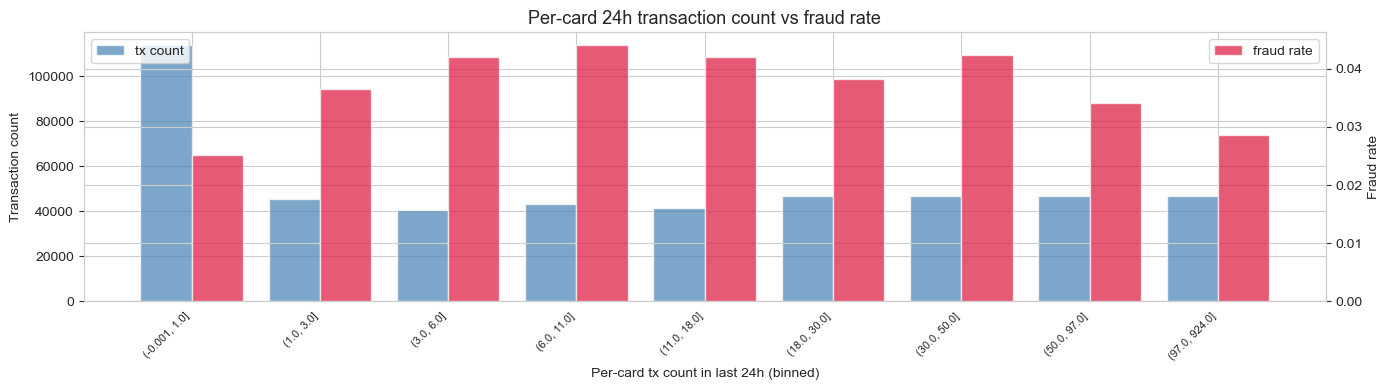

          bin  fraud_rate  tx_count
(-0.001, 1.0]    0.025142    113914
   (1.0, 3.0]    0.036590     45641
   (3.0, 6.0]    0.041959     40468
  (6.0, 11.0]    0.044057     43489
 (11.0, 18.0]    0.041935     41564
 (18.0, 30.0]    0.038255     46818
 (30.0, 50.0]    0.042296     46766
 (50.0, 97.0]    0.034043     46941
(97.0, 924.0]    0.028635     46831


In [25]:
# bin by quantile and calculate fraud rate per bin
tr_sorted["count_bin"] = pd.qcut(tr_sorted["card_tx_count_24h"], q=10, duplicates="drop")

bin_stats = (tr_sorted.groupby("count_bin", observed=True)["isFraud"]
               .agg(["mean", "count"])
               .reset_index()
               .rename(columns={"count_bin": "bin", "mean": "fraud_rate", "count": "tx_count"}))

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
x = range(len(bin_stats))
ax1.bar([i - 0.2 for i in x], bin_stats["tx_count"],   width=0.4, color="steelblue", alpha=0.7, label="tx count")
ax2.bar([i + 0.2 for i in x], bin_stats["fraud_rate"],  width=0.4, color="crimson",   alpha=0.7, label="fraud rate")
ax1.set_xticks(x)
ax1.set_xticklabels([str(b) for b in bin_stats["bin"]], rotation=45, ha="right", fontsize=8)
ax1.set_xlabel("Per-card tx count in last 24h (binned)")
ax1.set_title("Per-card 24h transaction count vs fraud rate")
ax1.set_ylabel("Transaction count")
ax2.set_ylabel("Fraud rate")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(bin_stats.to_string(index=False))

## 5. Numeric feature analysis — D15, dist1, C13

In [26]:
features_to_analyze = ["D15", "dist1", "C13"]

for col in features_to_analyze:
    missing = train[col].isna().mean() * 100
    print(f"=== {col} ===")
    print(train[col].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(2).to_string())
    print(f"missing : {missing:.2f}%")
    print(f"skewness: {train[col].skew():.2f}")
    print(f"negatives: {(train[col] < 0).sum()}")
    print()

=== D15 ===
count    501427.00
mean        163.74
std         202.73
min         -83.00
25%           0.00
50%          52.00
75%         314.00
90%         509.00
95%         566.00
99%         635.00
max         879.00
missing : 15.09%
skewness: 0.96
negatives: 15

=== dist1 ===
count    238269.00
mean        118.50
std         371.87
min           0.00
25%           3.00
50%           8.00
75%          24.00
90%         268.00
95%         846.00
99%        2040.00
max       10286.00
missing : 59.65%
skewness: 5.11
negatives: 0

=== C13 ===
count    590540.00
mean         32.54
std         129.36
min           0.00
25%           1.00
50%           3.00
75%          12.00
90%          37.00
95%         102.00
99%         578.00
max        2918.00
missing : 0.00%
skewness: 8.99
negatives: 0



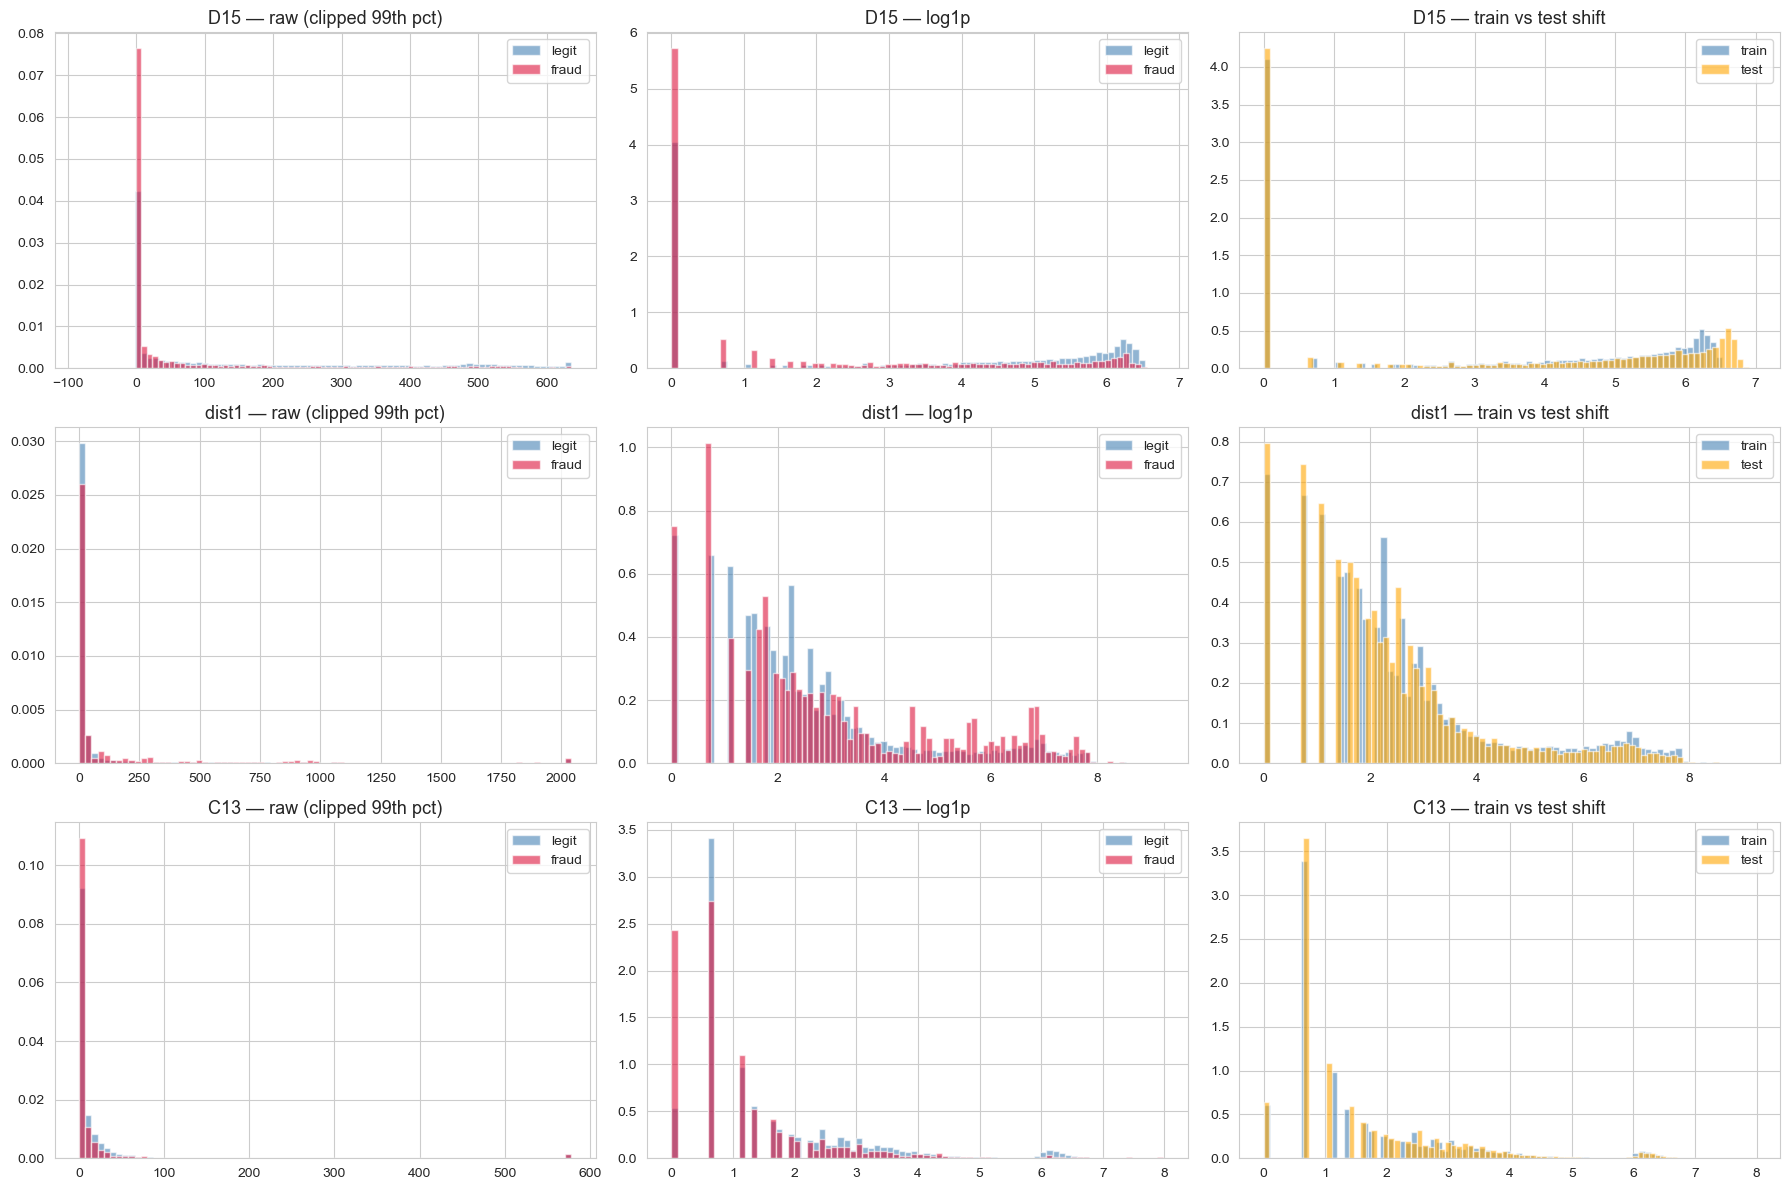

In [27]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, col in enumerate(features_to_analyze):
    legit = train.loc[train["isFraud"]==0, col].dropna()
    fraud = train.loc[train["isFraud"]==1, col].dropna()

    # raw distribution — clipped at 99th percentile
    clip_val = train[col].quantile(0.99)
    axes[row][0].hist(legit.clip(upper=clip_val), bins=80, color="steelblue", alpha=0.6, density=True, label="legit")
    axes[row][0].hist(fraud.clip(upper=clip_val), bins=80, color="crimson",   alpha=0.6, density=True, label="fraud")
    axes[row][0].set_title(f"{col} — raw (clipped 99th pct)")
    axes[row][0].legend()

    # log distribution
    axes[row][1].hist(np.log1p(legit.clip(lower=0)), bins=80, color="steelblue", alpha=0.6, density=True, label="legit")
    axes[row][1].hist(np.log1p(fraud.clip(lower=0)), bins=80, color="crimson",   alpha=0.6, density=True, label="fraud")
    axes[row][1].set_title(f"{col} — log1p")
    axes[row][1].legend()

    # train vs test shift
    axes[row][2].hist(np.log1p(train[col].clip(lower=0).dropna()), bins=80, color="steelblue", alpha=0.6, density=True, label="train")
    axes[row][2].hist(np.log1p(test[col].clip(lower=0).dropna()),  bins=80, color="orange",    alpha=0.6, density=True, label="test")
    axes[row][2].set_title(f"{col} — train vs test shift")
    axes[row][2].legend()

plt.tight_layout()
plt.show()

In [28]:
# KS test for train/test shift
print("=== KS test (train vs test distribution shift) ===")
for col in features_to_analyze:
    tr_vals   = train[col].dropna().values
    test_vals = test[col].dropna().values
    ks_stat, ks_p = stats.ks_2samp(tr_vals, test_vals)
    print(f"{col:8s}  KS={ks_stat:.4f}  p={ks_p:.2e}  {'** shift **' if ks_p < 0.05 else 'ok'}")

=== KS test (train vs test distribution shift) ===
D15       KS=0.1222  p=0.00e+00  ** shift **
dist1     KS=0.0339  p=1.26e-113  ** shift **
C13       KS=0.0081  p=9.07e-16  ** shift **


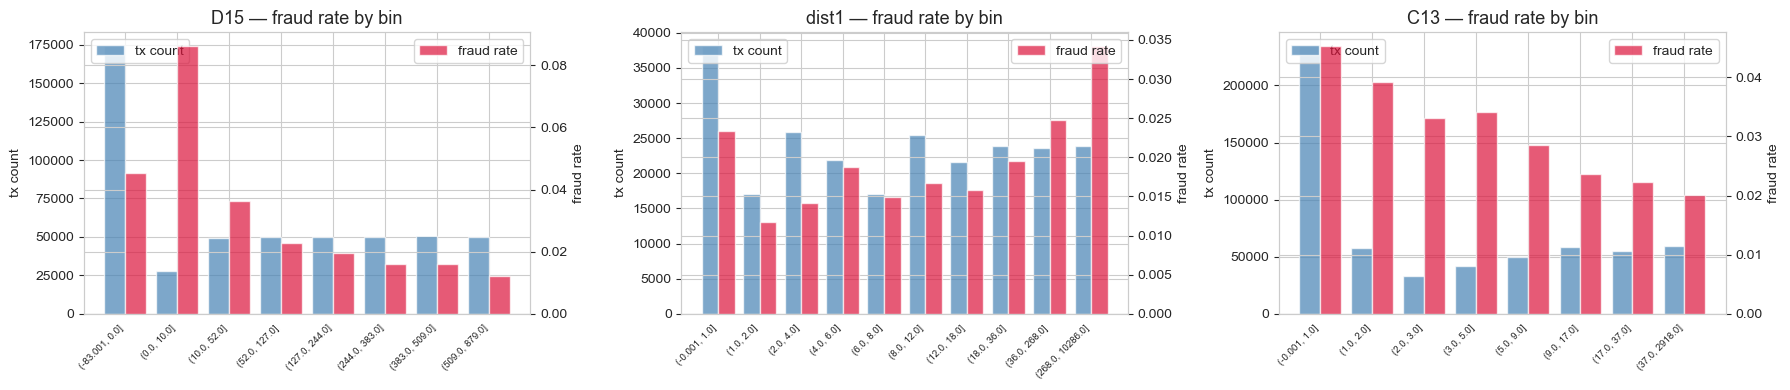

In [29]:
# fraud rate by quantile bin for each feature
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, features_to_analyze):
    tmp = train[[col, "isFraud"]].dropna()
    tmp["bin"] = pd.qcut(tmp[col], q=10, duplicates="drop")
    bin_stats = tmp.groupby("bin", observed=True)["isFraud"].agg(["mean", "count"]).reset_index()

    ax2 = ax.twinx()
    x = range(len(bin_stats))
    ax.bar([i - 0.2 for i in x],  bin_stats["count"],  width=0.4, color="steelblue", alpha=0.7, label="tx count")
    ax2.bar([i + 0.2 for i in x], bin_stats["mean"],   width=0.4, color="crimson",   alpha=0.7, label="fraud rate")
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in bin_stats["bin"]], rotation=45, ha="right", fontsize=7)
    ax.set_title(f"{col} — fraud rate by bin")
    ax.set_ylabel("tx count")
    ax2.set_ylabel("fraud rate")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 6. Skewness distribution across all numeric features

In [34]:
### delete_unused_cols
delete_cols = ['id_29', 'V191', 'V196', 'V28', 'V241', 'V107', 'V117', 'V119', 'V120', 'V113', 'V305', 'V88', 'V89', 'V27', 'V41', 'V65', 'V325', 'V327', 'V68', 'id_16', 'id_27']
cat_fea = ['ProductCD','card1','card2','card3','card4','card5','card6','addr1','addr2','P_emaildomain','R_emaildomain','DeviceType','DeviceInfo']

for i in range(1,10):
    if 'M'+str(i) not in delete_cols:
        cat_fea.append('M'+str(i))
for i in range(12,39):
    if 'id_'+str(i) not in delete_cols:
        cat_fea.append('id_'+str(i))

num_fea = [] #46
for fea in train.columns:
    if fea not in ['TransactionID','isFraud'] and fea not in cat_fea and fea not in delete_cols:
        num_fea.append(fea)

In [35]:
# compute skewness for all numeric features
num_cols = train[num_fea].select_dtypes(include=[np.number]).columns.tolist()
skew_df = (train[num_cols]
           .skew()
           .reset_index()
           .rename(columns={'index': 'feature', 0: 'skewness'})
           .sort_values('skewness', ascending=False)
           .reset_index(drop=True))

print(f"Total numeric features: {len(skew_df)}")
print(f"Skewness summary:")
print(skew_df['skewness'].describe(percentiles=[.1,.25,.5,.75,.9]).round(2).to_string())
print(f"Highly skewed  (|skew| > 10) : {(skew_df['skewness'].abs() > 10).sum()}")
print(f"Moderately skewed (1-10)     : {((skew_df['skewness'].abs() > 1) & (skew_df['skewness'].abs() <= 10)).sum()}")
print(f"Approx normal  (|skew| <= 1) : {(skew_df['skewness'].abs() <= 1).sum()}")

Total numeric features: 374
Skewness summary:
count    374.00
mean      20.36
std       37.45
min     -135.30
10%        0.46
25%        3.31
50%       10.55
75%       23.88
90%       41.05
max      323.83
Highly skewed  (|skew| > 10) : 198
Moderately skewed (1-10)     : 139
Approx normal  (|skew| <= 1) : 37


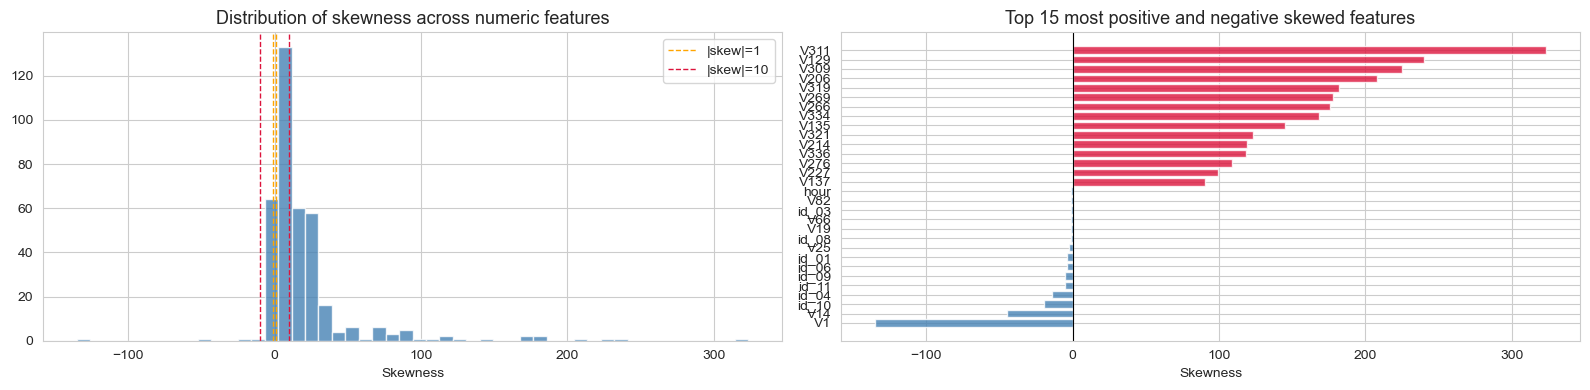

Top 10 most positively skewed:
feature   skewness
   V311 323.831374
   V129 240.274253
   V309 224.875268
   V206 207.881617
   V319 181.833654
   V269 177.838951
   V266 175.958772
   V334 168.472807
   V135 144.883182
   V321 123.556475
Top 10 most negatively skewed:
feature    skewness
  id_08   -1.016080
    V25   -2.648066
  id_01   -3.669742
  id_06   -3.903552
  id_09   -4.802845
  id_11   -4.825067
  id_04  -14.289811
  id_10  -19.482443
    V14  -44.708269
     V1 -135.300320


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# histogram of skewness values
axes[0].hist(skew_df['skewness'], bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline( 1, color='orange', linestyle='--', linewidth=1, label='|skew|=1')
axes[0].axvline(-1, color='orange', linestyle='--', linewidth=1)
axes[0].axvline( 10, color='crimson', linestyle='--', linewidth=1, label='|skew|=10')
axes[0].axvline(-10, color='crimson', linestyle='--', linewidth=1)
axes[0].set_xlabel('Skewness')
axes[0].set_title('Distribution of skewness across numeric features')
axes[0].legend()

# sorted bar chart — top 30 most skewed
top30 = pd.concat([skew_df.head(15), skew_df.tail(15)]).reset_index(drop=True)
colors = ['crimson' if s > 0 else 'steelblue' for s in top30['skewness']]
axes[1].barh(top30['feature'], top30['skewness'], color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Skewness')
axes[1].set_title('Top 15 most positive and negative skewed features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 most positively skewed:")
print(skew_df.head(10).to_string(index=False))
print("Top 10 most negatively skewed:")
print(skew_df.tail(10).to_string(index=False))

In [ ]:
# apply log1p to numeric features with skewness > 10
high_skew_cols = skew_df.loc[skew_df["skewness"] > 10, "feature"].tolist()
print(f"Features to log transform ({len(high_skew_cols)}): {high_skew_cols}")

for df in [tr_sorted, val_sorted, test_sorted]:
    for col in high_skew_cols:
        if col in df.columns:
            df[col] = np.log1p(df[col].clip(lower=0))

print("Done — log1p applied to all splits.")

In [ ]:
# bin D15 into quantile buckets using tr only — no leakage
n_bins = 10
D15_bins = pd.qcut(tr_sorted["D15"].rank(method="first"), q=n_bins, labels=False, duplicates="drop")
bin_edges = pd.qcut(tr_sorted["D15"], q=n_bins, retbins=True, duplicates="drop")[1]

tr_sorted["D15_bin"]   = pd.cut(tr_sorted["D15"],  bins=bin_edges, labels=False, include_lowest=True).astype("category")
val_sorted["D15_bin"]  = pd.cut(val_sorted["D15"],  bins=bin_edges, labels=False, include_lowest=True).astype("category")
test_sorted["D15_bin"] = pd.cut(test_sorted["D15"], bins=bin_edges, labels=False, include_lowest=True).astype("category")

print(f"Bin edges: {bin_edges.round(2)}")
print(f"tr  D15_bin value counts:
{tr_sorted['D15_bin'].value_counts().sort_index()}")

## 7. Combined rolling features — 24h fraud count & ratio per entity

For each transaction at time *t*, look back 24h on the same entity (card1, card2, addr1, P_emaildomain) and compute:
- : total transactions in window
- : fraud transactions in window
- : fraud count / total count

All stats computed from tr only — no leakage into val/test.

In [38]:
def rolling_fraud_stats(base_df, target_df, col, window=86400):
    """
    For each row in target_df, look back window seconds on same entity in base_df.
    When base_df == target_df (tr self-join), upper bound is t-1 to exclude current row.
    """
    is_self = base_df is target_df
    base_s = base_df[[col, "TransactionDT", "isFraud"]].sort_values("TransactionDT")
    target_s = target_df[[col, "TransactionDT"]].copy()
    target_s["_pos"] = np.arange(len(target_s))

    tx_counts    = np.zeros(len(target_s), dtype=np.int32)
    fraud_counts = np.zeros(len(target_s), dtype=np.int32)

    for entity, grp in target_s.groupby(col):
        dt_target = grp["TransactionDT"].values
        base_grp  = base_s[base_s[col] == entity]
        dt_base   = base_grp["TransactionDT"].values
        fraud_base = base_grp["isFraud"].values

        if len(dt_base) == 0:
            continue

        left  = np.searchsorted(dt_base, dt_target - window, side="left")
        # exclude current row when computing on tr itself
        right = np.searchsorted(dt_base, dt_target - 1 if is_self else dt_target, side="right")

        pos = grp["_pos"].values
        tx_counts[pos]    = right - left
        fraud_counts[pos] = np.array([fraud_base[l:r].sum() for l, r in zip(left, right)])

    fraud_ratio = np.where(tx_counts > 0, fraud_counts / tx_counts, np.nan)
    return tx_counts, fraud_counts, fraud_ratio

entities = ["card1", "card2", "addr1", "P_emaildomain"]

tr_s  = tr.sort_values("TransactionDT").reset_index(drop=True)
val_s = val.sort_values("TransactionDT").reset_index(drop=True)

for col in entities:
    print(f"Computing {col}...")
    tx, fc, fr = rolling_fraud_stats(tr_s, tr_s, col)
    tr_s[col + "_tx_count_24h"]    = tx
    tr_s[col + "_fraud_count_24h"] = fc
    tr_s[col + "_fraud_ratio_24h"] = fr

    tx, fc, fr = rolling_fraud_stats(tr_s, val_s, col)
    val_s[col + "_tx_count_24h"]    = tx
    val_s[col + "_fraud_count_24h"] = fc
    val_s[col + "_fraud_ratio_24h"] = fr

print("Done.")

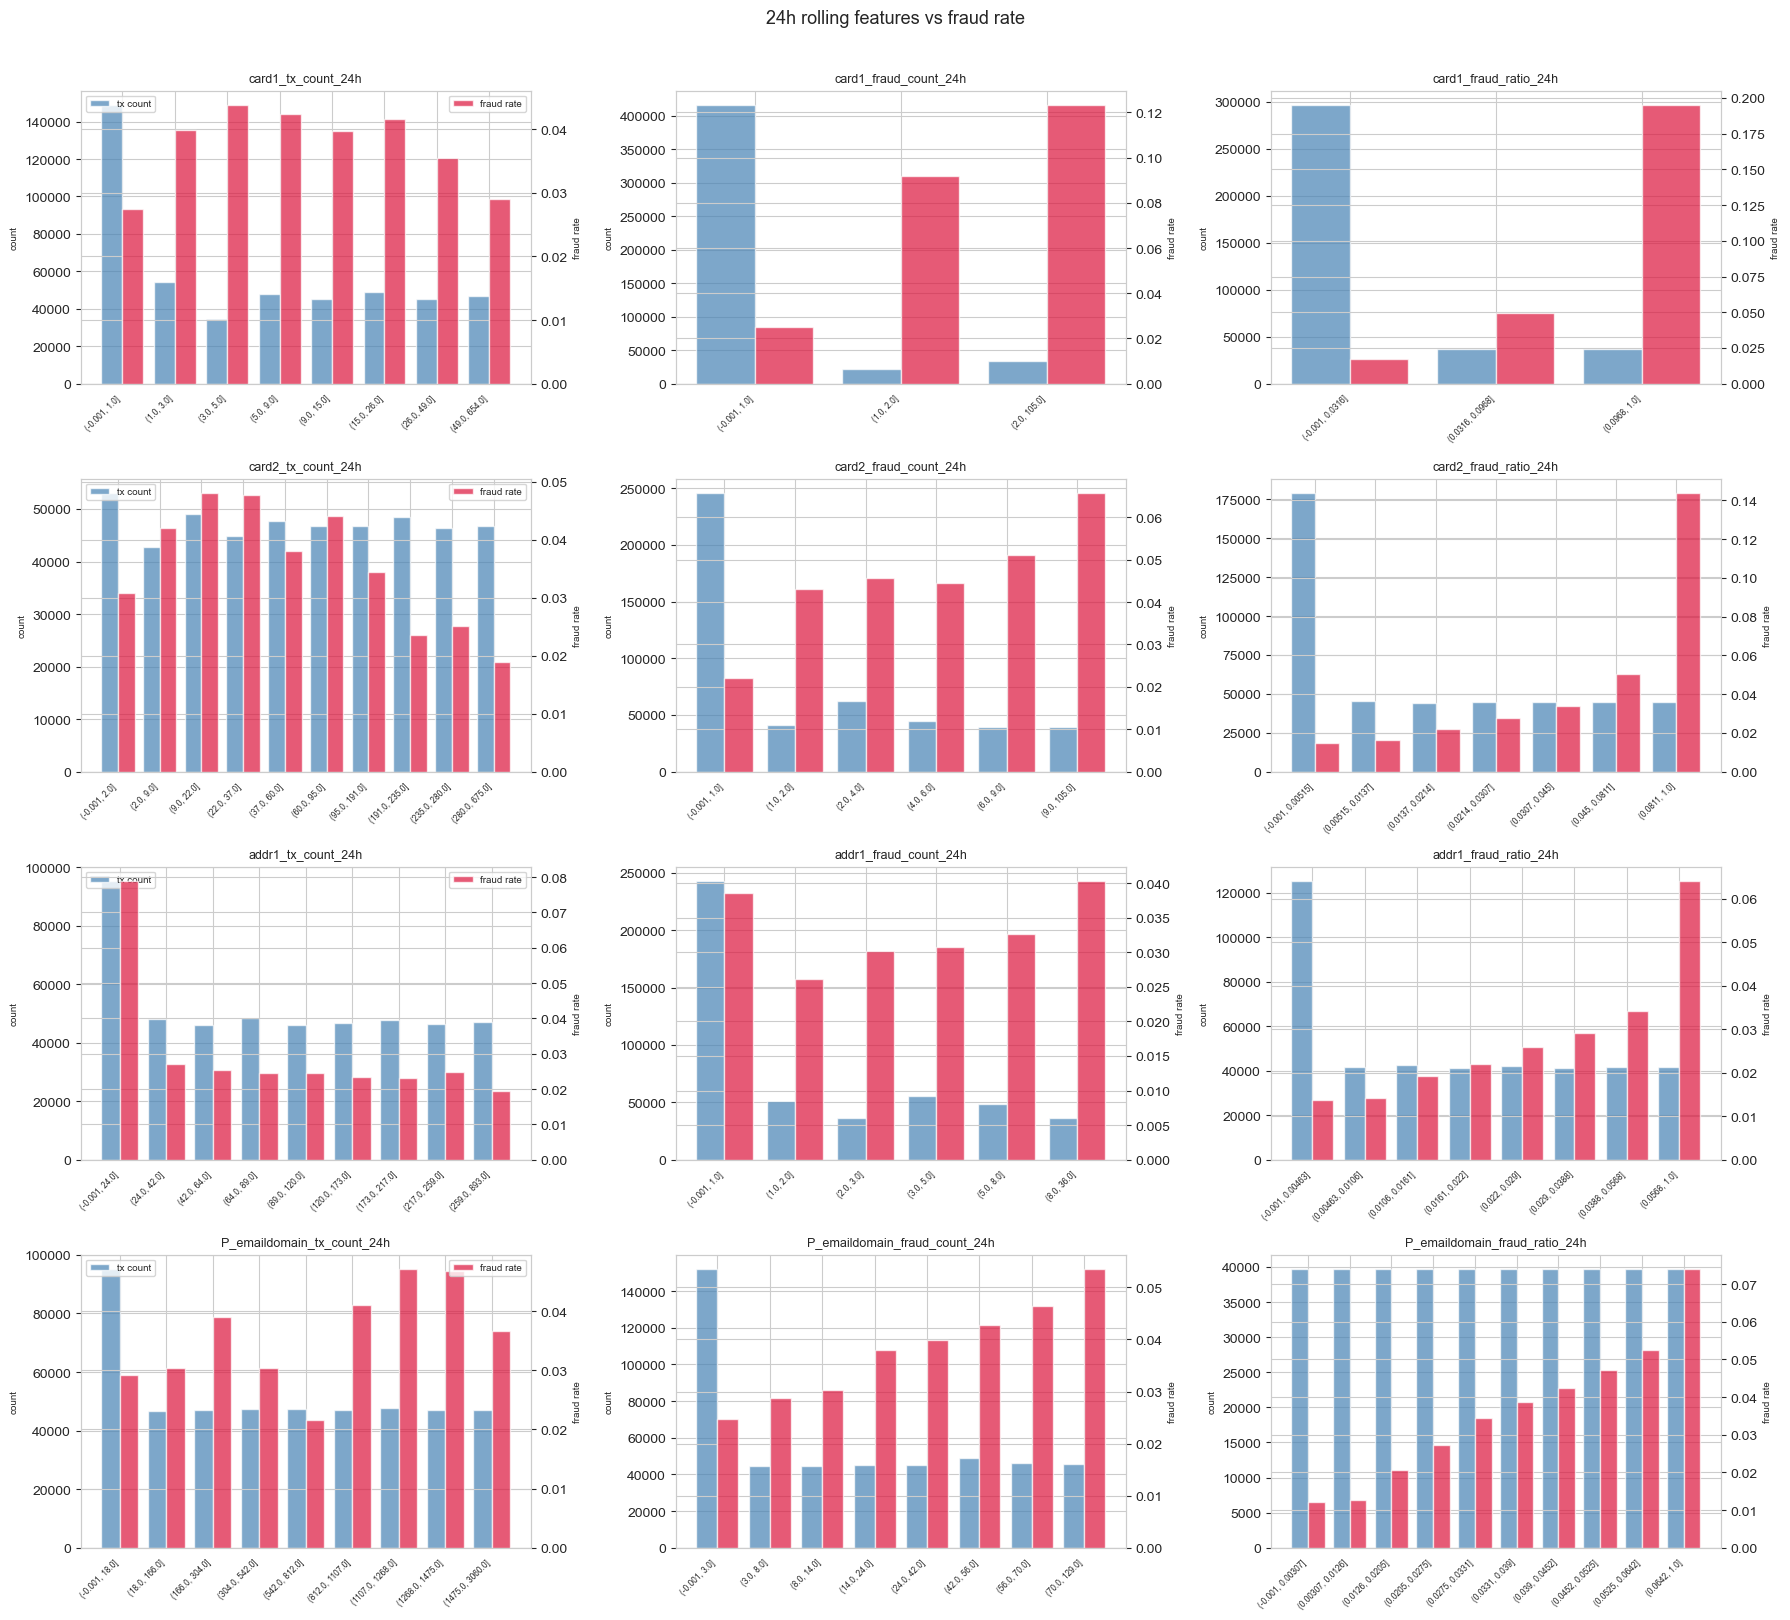

In [39]:
# analyze relationship with isFraud for each new feature
new_cols = [col + suf
            for col in entities
            for suf in ["_tx_count_24h", "_fraud_count_24h", "_fraud_ratio_24h"]]

fig, axes = plt.subplots(len(entities), 3, figsize=(18, 4 * len(entities)))

for row, col in enumerate(entities):
    for ax_col, suf in enumerate(["_tx_count_24h", "_fraud_count_24h", "_fraud_ratio_24h"]):
        feat = col + suf
        ax = axes[row][ax_col]
        ax2 = ax.twinx()

        tmp = tr_s[[feat, "isFraud"]].dropna()
        tmp["bin"] = pd.qcut(tmp[feat], q=10, duplicates="drop")
        stats = tmp.groupby("bin", observed=True)["isFraud"].agg(["mean", "count"]).reset_index()

        x = range(len(stats))
        ax.bar([i - 0.2 for i in x],  stats["count"], width=0.4, color="steelblue", alpha=0.7, label="tx count")
        ax2.bar([i + 0.2 for i in x], stats["mean"],  width=0.4, color="crimson",   alpha=0.7, label="fraud rate")
        ax.set_xticks(x)
        ax.set_xticklabels([str(b) for b in stats["bin"]], rotation=45, ha="right", fontsize=6)
        ax.set_title(feat, fontsize=9)
        ax.set_ylabel("count", fontsize=7)
        ax2.set_ylabel("fraud rate", fontsize=7)
        if ax_col == 0:
            ax.legend(loc="upper left", fontsize=7)
            ax2.legend(loc="upper right", fontsize=7)

plt.suptitle("24h rolling features vs fraud rate", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [40]:
# summary stats — fraud rate spread per feature (max - min across bins)
print(f"{'Feature':<35} {'min_fraud':>10} {'max_fraud':>10} {'spread':>10}")
print("-" * 65)
for feat in new_cols:
    tmp = tr_s[[feat, "isFraud"]].dropna()
    if tmp[feat].nunique() < 2:
        continue
    tmp["bin"] = pd.qcut(tmp[feat], q=10, duplicates="drop")
    stats = tmp.groupby("bin", observed=True)["isFraud"].mean()
    spread = stats.max() - stats.min()
    print(f"{feat:<35} {stats.min():>10.4f} {stats.max():>10.4f} {spread:>10.4f}")

Feature                              min_fraud  max_fraud     spread
-----------------------------------------------------------------
card1_tx_count_24h                      0.0274     0.0439     0.0164
card1_fraud_count_24h                   0.0249     0.1235     0.0985
card1_fraud_ratio_24h                   0.0171     0.1953     0.1783
card2_tx_count_24h                      0.0189     0.0481     0.0293
card2_fraud_count_24h                   0.0220     0.0658     0.0438
card2_fraud_ratio_24h                   0.0148     0.1440     0.1292
addr1_tx_count_24h                      0.0196     0.0790     0.0594
addr1_fraud_count_24h                   0.0261     0.0404     0.0143
addr1_fraud_ratio_24h                   0.0137     0.0641     0.0504
P_emaildomain_tx_count_24h              0.0216     0.0472     0.0256
P_emaildomain_fraud_count_24h           0.0247     0.0536     0.0289
P_emaildomain_fraud_ratio_24h           0.0120     0.0741     0.0621


## 8. Fraud count by entity — top 10 per group\n\nGroup by each high-cardinality entity and compute total transactions, fraud count, and fraud rate.\nTop 10 sorted by fraud count (absolute number of fraud cases).

In [5]:
entities = ['card1', 'card2', 'addr1', 'P_emaildomain', 'card5']

for col in entities:
    stats = (train.groupby(col)['isFraud']
             .agg(total='count', fraud_cnt='sum')
             .assign(fraud_rate=lambda x: x['fraud_cnt'] / x['total'])
             .sort_values('fraud_rate', ascending=False)
             .head(10)
             .reset_index())
    print(f"=== Top 10 by fraud count — {col} ===")
    print(stats.to_string(index=False))
    print()

=== Top 10 by fraud count — card1 ===
 card1  total  fraud_cnt  fraud_rate
 10320      4          4         1.0
 14671      3          3         1.0
  8185      1          1         1.0
 11292      1          1         1.0
 15042      5          5         1.0
 11228      1          1         1.0
  4895      1          1         1.0
 15053      1          1         1.0
  4817      1          1         1.0
  4788      1          1         1.0

=== Top 10 by fraud count — card2 ===
 card2  total  fraud_cnt  fraud_rate
 289.0    118         48    0.406780
 405.0    228         92    0.403509
 319.0    100         39    0.390000
 176.0    513        185    0.360624
 482.0    168         55    0.327381
 407.0     56         17    0.303571
 311.0    289         81    0.280277
 104.0    754        187    0.248011
 324.0    331         80    0.241692
 177.0   1642        396    0.241169

=== Top 10 by fraud count — addr1 ===
 addr1  total  fraud_cnt  fraud_rate
 305.0      9          6    0.666

## 9. Train vs Test distribution — high-cardinality categorical features

For each of `card1`, `card2`, `addr1`, `P_emaildomain`, `card5`:
- **Coverage**: unique value counts and % of test values unseen in train
- **Frequency distribution**: how spread out are the entity counts (log scale)
- **Top-value overlap**: top 20 train values — their rank and share in test
- **Value frequency shift**: KS test on the per-entity frequency vectors

In [8]:
cols = ['card1', 'card2', 'addr1', 'P_emaildomain', 'card5']

# ── 9.1  Coverage summary ─────────────────────────────────────────────────────
print(f"{'Feature':<18} {'Train uniq':>10} {'Test uniq':>10} {'Unknown in test':>16} {'Unknown %':>10}")
print("-" * 68)
for col in cols:
    train_vals = set(train[col].dropna().unique())
    test_vals  = set(test[col].dropna().unique())
    unknown    = test_vals - train_vals
    unknown_pct = test[col].isin(unknown).mean() * 100
    print(f"{col:<18} {len(train_vals):>10,} {len(test_vals):>10,} {len(unknown):>16,} {unknown_pct:>9.2f}%")

Feature            Train uniq  Test uniq  Unknown in test  Unknown %
--------------------------------------------------------------------
card1                  13,553     13,244            3,538      1.85%
card2                     500        497                1      0.03%
addr1                     332        292              109      0.03%
P_emaildomain              59         60                1      0.00%
card5                     119        102               19      0.01%


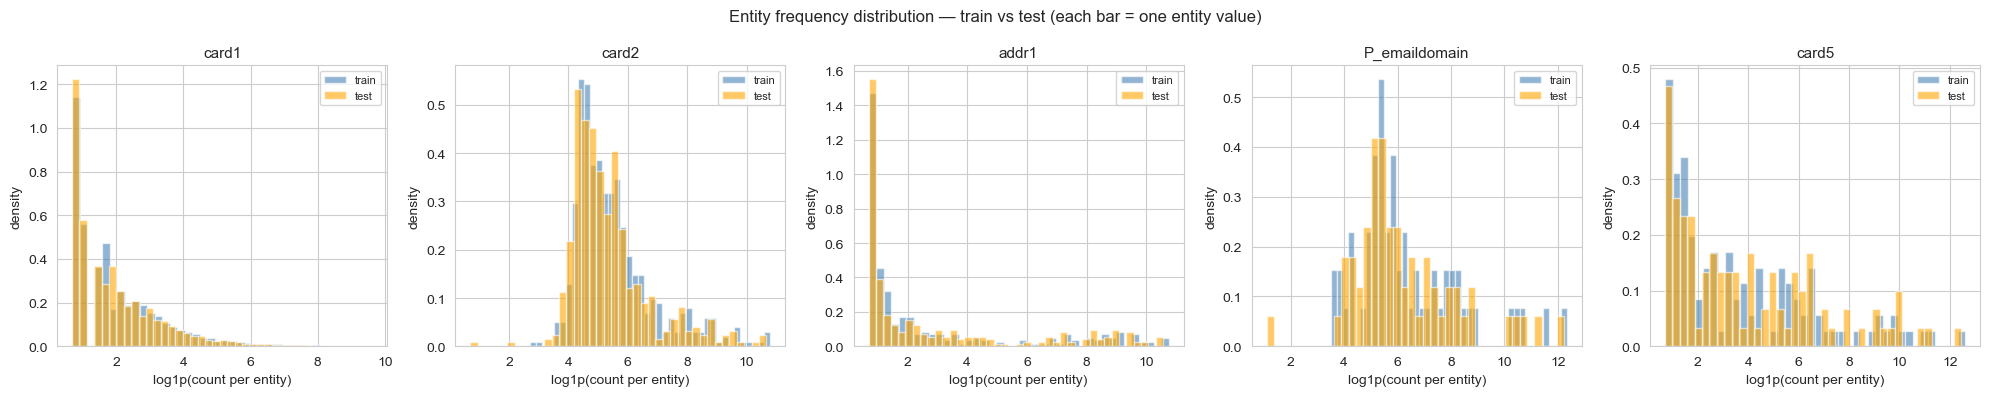

In [9]:
# ── 9.2  Frequency distribution — train vs test (log scale) ──────────────────
fig, axes = plt.subplots(1, len(cols), figsize=(20, 4))

for ax, col in zip(axes, cols):
    tr_counts   = train[col].value_counts()
    test_counts = test[col].value_counts()

    ax.hist(np.log1p(tr_counts.values),   bins=40, alpha=0.6, color='steelblue', density=True, label='train')
    ax.hist(np.log1p(test_counts.values), bins=40, alpha=0.6, color='orange',    density=True, label='test')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('log1p(count per entity)')
    ax.set_ylabel('density')
    ax.legend(fontsize=8)

fig.suptitle('Entity frequency distribution — train vs test (each bar = one entity value)', fontsize=12)
plt.tight_layout()
plt.show()

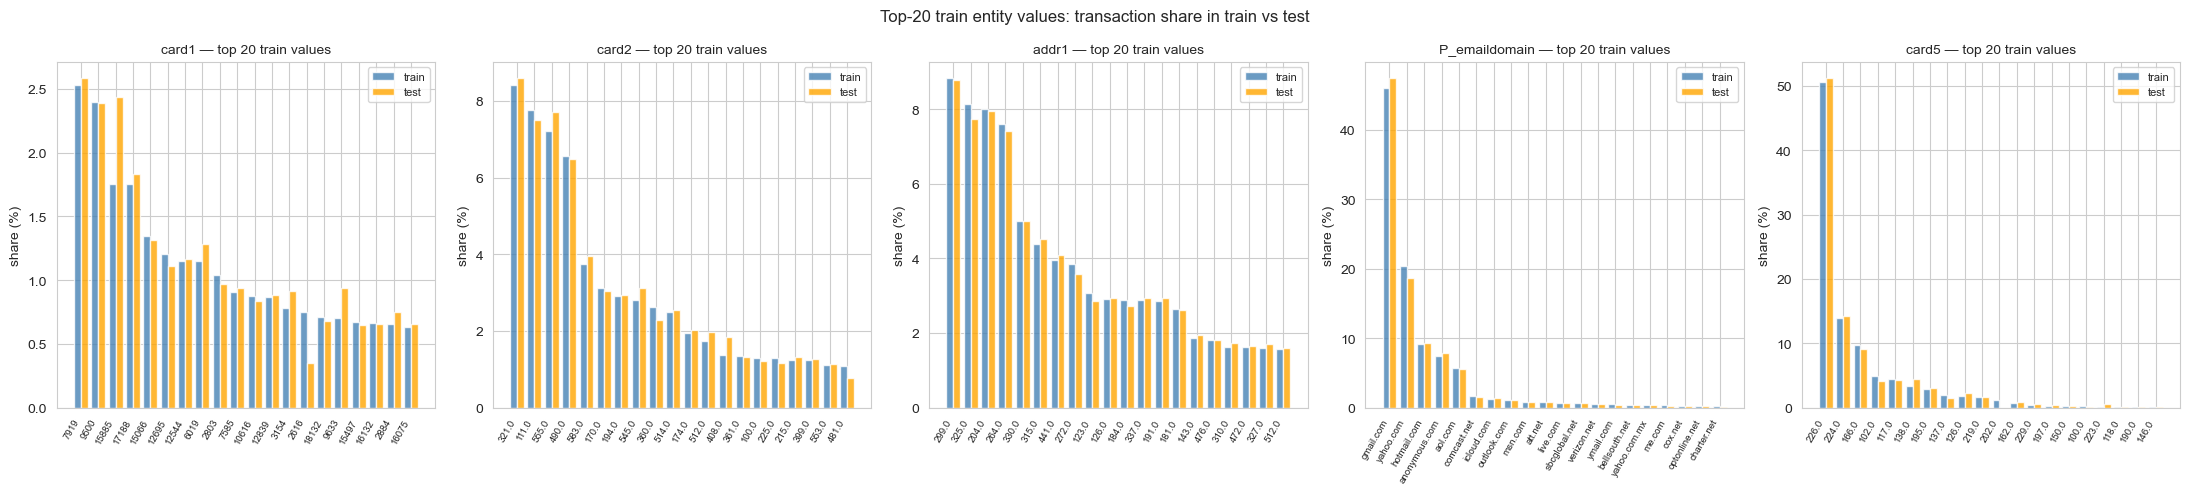

In [10]:
# ── 9.3  Top-20 train values — share in train vs test ────────────────────────
n_top = 20
fig, axes = plt.subplots(1, len(cols), figsize=(22, 5))

for ax, col in zip(axes, cols):
    tr_freq   = train[col].value_counts(normalize=True)
    test_freq = test[col].value_counts(normalize=True)
    top_vals  = tr_freq.head(n_top).index

    tr_share   = tr_freq.reindex(top_vals).fillna(0).values * 100
    test_share = test_freq.reindex(top_vals).fillna(0).values * 100

    x = np.arange(n_top)
    ax.bar(x - 0.2, tr_share,   width=0.4, color='steelblue', alpha=0.8, label='train')
    ax.bar(x + 0.2, test_share, width=0.4, color='orange',    alpha=0.8, label='test')
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in top_vals], rotation=60, ha='right', fontsize=7)
    ax.set_title(f'{col} — top {n_top} train values', fontsize=10)
    ax.set_ylabel('share (%)')
    ax.legend(fontsize=8)

fig.suptitle('Top-20 train entity values: transaction share in train vs test', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# ── 9.4  KS test on per-entity frequency vectors + numeric summary ────────────
print(f"{'Feature':<18} {'KS stat':>8} {'p-value':>12}  {'Shift?'}")
print("-" * 55)

for col in cols:
    tr_freq   = train[col].value_counts(normalize=True)
    test_freq = test[col].value_counts(normalize=True)
    # align on shared entities only
    shared = tr_freq.index.intersection(test_freq.index)
    if len(shared) < 2:
        print(f"{col:<18}  (not enough shared values)")
        continue
    ks_stat, ks_p = stats.ks_2samp(tr_freq.loc[shared].values,
                                    test_freq.loc[shared].values)
    flag = '** shift **' if ks_p < 0.05 else 'ok'
    print(f"{col:<18} {ks_stat:>8.4f} {ks_p:>12.2e}  {flag}")

print()

# detailed numeric summary per feature
for col in cols:
    tr_freq   = train[col].value_counts()
    test_freq = test[col].value_counts()
    shared_pct = test[col].isin(train[col].unique()).mean() * 100
    print(f"--- {col} ---")
    print(f"  train: {len(tr_freq):,} unique  |  median freq {tr_freq.median():.0f}  |  max freq {tr_freq.max():,}")
    print(f"  test : {len(test_freq):,} unique  |  median freq {test_freq.median():.0f}  |  max freq {test_freq.max():,}")
    print(f"  test rows with known train value: {shared_pct:.1f}%")
    print()

Feature             KS stat      p-value  Shift?
-------------------------------------------------------


AttributeError: 'DataFrame' object has no attribute 'ks_2samp'

In [26]:
train['D1']

0          14.0
1           0.0
2           0.0
3         112.0
4           0.0
          ...  
590535     29.0
590536      0.0
590537      0.0
590538     22.0
590539      0.0
Name: D1, Length: 590540, dtype: float64

## 10. User ID — transaction count per uid

`D1_norm = TransactionDT - D1 * 86400` is constant for all transactions from the same card,
making `card1 + addr1 + D1_norm` a stable pseudo user identifier.

In [37]:
# ── build uid ─────────────────────────────────────────────────────────────────
train['D1_norm'] = (train['TransactionDT']  // 86400).astype(int) - train['D1']
train['uid'] = (train['card1'].astype(str) + '_' +
                train['addr1'].astype(str) + '_' + train['D1_norm'].astype(str))





####other uid ####

# coarse — might cover multiple customers
train['uid1'] = train['card1'].astype(str) + '_' + \
                train['card2'].astype(str)

# medium
train['uid2'] = train['card1'].astype(str) + '_' + \
                train['addr1'].astype(str)

# most fine — add email
train['uid4'] = train['card1'].astype(str) + '_' + \
                train['addr1'].astype(str) + '_' + \
                train['P_emaildomain'].astype(str)


key = 'uid'
# ── transaction count per uid ─────────────────────────────────────────────────
uid_tx_count = train.groupby(key)['TransactionID'].count().rename('tx_count')




print(f"Total UIDs             : {len(uid_tx_count):,}")
print(f"Avg tx count per uid   : {uid_tx_count.mean():.2f}")
print(f"Median tx count        : {uid_tx_count.median():.0f}")
print()
print("=== tx_count distribution ===")
print(uid_tx_count.describe(percentiles=[.5,.75,.9,.95,.99]).round(2))
print()
print(f"Single-tx UIDs  : {(uid_tx_count == 1).sum():,}  ({(uid_tx_count == 1).mean()*100:.1f}%)")
print(f"2–5 tx UIDs     : {uid_tx_count.between(2, 5).sum():,}  ({uid_tx_count.between(2,5).mean()*100:.1f}%)")
print(f"6–20 tx UIDs    : {uid_tx_count.between(6, 20).sum():,}  ({uid_tx_count.between(6,20).mean()*100:.1f}%)")
print(f">20 tx UIDs     : {(uid_tx_count > 20).sum():,}  ({(uid_tx_count > 20).mean()*100:.1f}%)")

print()
print("=== Top 10 UIDs by transaction count ===")
top_uids = uid_tx_count.sort_values(ascending=False).head(10).reset_index()
top_uids['fraud_cnt'] = top_uids[key].map(
    train.groupby(key)['isFraud'].sum()
)
top_uids['fraud_rate'] = (top_uids['fraud_cnt'] / top_uids['tx_count']).round(3)
print(top_uids.to_string(index=False))

Total UIDs             : 217,850
Avg tx count per uid   : 2.71
Median tx count        : 1

=== tx_count distribution ===
count    217850.00
mean          2.71
std           5.46
min           1.00
50%           1.00
75%           3.00
90%           6.00
95%           9.00
99%          20.00
max        1414.00
Name: tx_count, dtype: float64

Single-tx UIDs  : 125,222  (57.5%)
2–5 tx UIDs     : 69,763  (32.0%)
6–20 tx UIDs    : 20,691  (9.5%)
>20 tx UIDs     : 2,174  (1.0%)

=== Top 10 UIDs by transaction count ===
               uid  tx_count  fraud_cnt  fraud_rate
 15775_330.0_129.0      1414          0       0.000
  9500_126.0_-85.0       446          0       0.000
  8900_231.0_-60.0       232          0       0.000
 8528_387.0_-159.0       215          0       0.000
  12616_nan_-491.0       211         37       0.175
12741_143.0_-202.0       196          0       0.000
 7207_204.0_-465.0       191          0       0.000
    15885_nan_22.0       174          2       0.011
 13597_191.0_

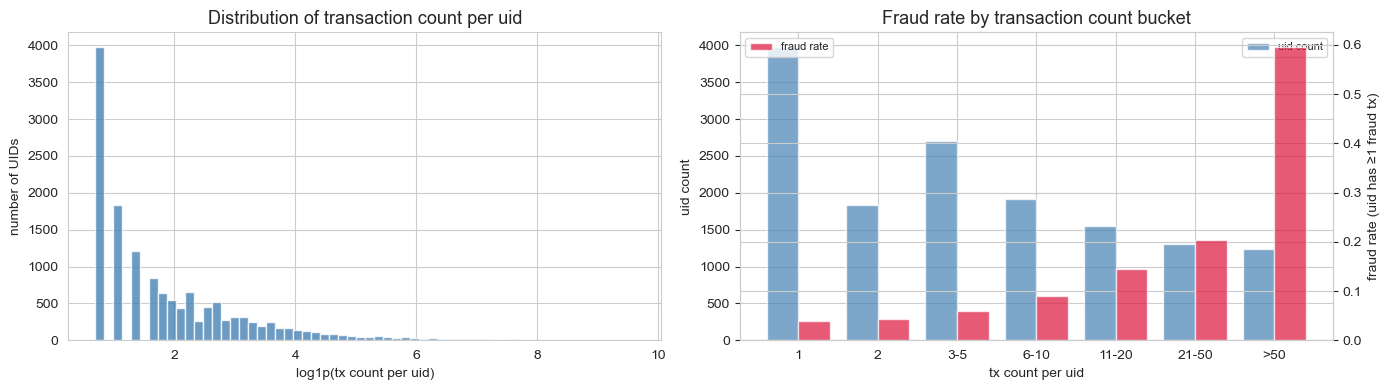

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# distribution of tx count per uid (log scale x-axis)
axes[0].hist(np.log1p(uid_tx_count.values), bins=60, color='steelblue', alpha=0.8)
axes[0].set_xlabel('log1p(tx count per uid)')
axes[0].set_ylabel('number of UIDs')
axes[0].set_title('Distribution of transaction count per uid')

# fraud rate by tx count bin
uid_fraud = train.groupby(key)['isFraud'].sum().rename('fraud_cnt')
uid_df = pd.concat([uid_tx_count, uid_fraud], axis=1).reset_index()
uid_df['has_fraud'] = (uid_df['fraud_cnt'] > 0).astype(int)
uid_df['tx_bin'] = pd.cut(uid_df['tx_count'],
                           bins=[0,1,2,5,10,20,50,uid_df['tx_count'].max()+1],
                           labels=['1','2','3-5','6-10','11-20','21-50','>50'])

bin_stats = uid_df.groupby('tx_bin', observed=True)['has_fraud'].agg(['mean','count']).reset_index()
ax2 = axes[1].twinx()
x = range(len(bin_stats))
axes[1].bar([i - 0.2 for i in x], bin_stats['count'], width=0.4, color='steelblue', alpha=0.7, label='uid count')
ax2.bar(    [i + 0.2 for i in x], bin_stats['mean'],  width=0.4, color='crimson',   alpha=0.7, label='fraud rate')
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_stats['tx_bin'].astype(str))
axes[1].set_xlabel('tx count per uid')
axes[1].set_ylabel('uid count')
ax2.set_ylabel('fraud rate (uid has ≥1 fraud tx)')
axes[1].set_title('Fraud rate by transaction count bucket')
axes[1].legend(loc='upper right', fontsize=8)
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 11. Per-user frequency — has this user used this ProductCD / P_emaildomain / R_emaildomain before?

For each transaction, independently check how many times the **same user** (`user_id1`) has previously used the same value of `ProductCD`, `P_emaildomain`, `R_emaildomain`.

- `user_id1` = `card1 + addr1 + D1_norm` where `D1_norm = (TransactionDT // 86400) - D1`
- Each feature validated **separately** — 0 means first time for that user, N means seen N times before
- Computed on time-sorted data using `cumcount()` — no leakage

In [52]:
# ── build user_id1 ────────────────────────────────────────────────────────────
train['D1_norm']  = (train['TransactionDT'] // 86400).astype(int) - train['D1'].fillna(-1).astype(int)
train['user_id1'] = (train['card1'].astype(str) + '_' +
                     train['addr1'].astype(str) + '_' +
                     train['D1_norm'].astype(str))

train_s = train.sort_values('TransactionDT').copy()

# ── compute per-user frequency for each feature independently ──────────────────
check_cols = ['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2',
           'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo']

for col in check_cols:
    feat = f'uid_{col}_freq_before'
    train_s[feat] = train_s.groupby(['user_id1', col], dropna=False).cumcount()

# ── summary stats ──────────────────────────────────────────────────────────────
for col in check_cols:
    feat = f'uid_{col}_freq_before'
    s = train_s[feat]
    never  = (s == 0).sum()
    repeat = (s >  0).sum()
    fr_new    = train_s.loc[s == 0, 'isFraud'].mean()
    fr_repeat = train_s.loc[s >  0, 'isFraud'].mean()
    print(f"--- {col} ---")
    print(f"  first-time (freq=0): {never:,}  ({never/len(train_s)*100:.1f}%)   fraud rate: {fr_new:.4f}")
    print(f"  repeat     (freq>0): {repeat:,}  ({repeat/len(train_s)*100:.1f}%)   fraud rate: {fr_repeat:.4f}")
    print()

--- ProductCD ---
  first-time (freq=0): 228,111  (38.6%)   fraud rate: 0.0276
  repeat     (freq>0): 362,429  (61.4%)   fraud rate: 0.0396

--- card1 ---
  first-time (freq=0): 217,735  (36.9%)   fraud rate: 0.0277
  repeat     (freq>0): 372,805  (63.1%)   fraud rate: 0.0392

--- card2 ---
  first-time (freq=0): 219,859  (37.2%)   fraud rate: 0.0278
  repeat     (freq>0): 370,681  (62.8%)   fraud rate: 0.0392

--- card3 ---
  first-time (freq=0): 218,770  (37.0%)   fraud rate: 0.0277
  repeat     (freq>0): 371,770  (63.0%)   fraud rate: 0.0393

--- card4 ---
  first-time (freq=0): 218,738  (37.0%)   fraud rate: 0.0277
  repeat     (freq>0): 371,802  (63.0%)   fraud rate: 0.0393

--- card5 ---
  first-time (freq=0): 221,257  (37.5%)   fraud rate: 0.0275
  repeat     (freq>0): 369,283  (62.5%)   fraud rate: 0.0395

--- card6 ---
  first-time (freq=0): 218,887  (37.1%)   fraud rate: 0.0277
  repeat     (freq>0): 371,653  (62.9%)   fraud rate: 0.0393

--- addr1 ---
  first-time (freq=0): 

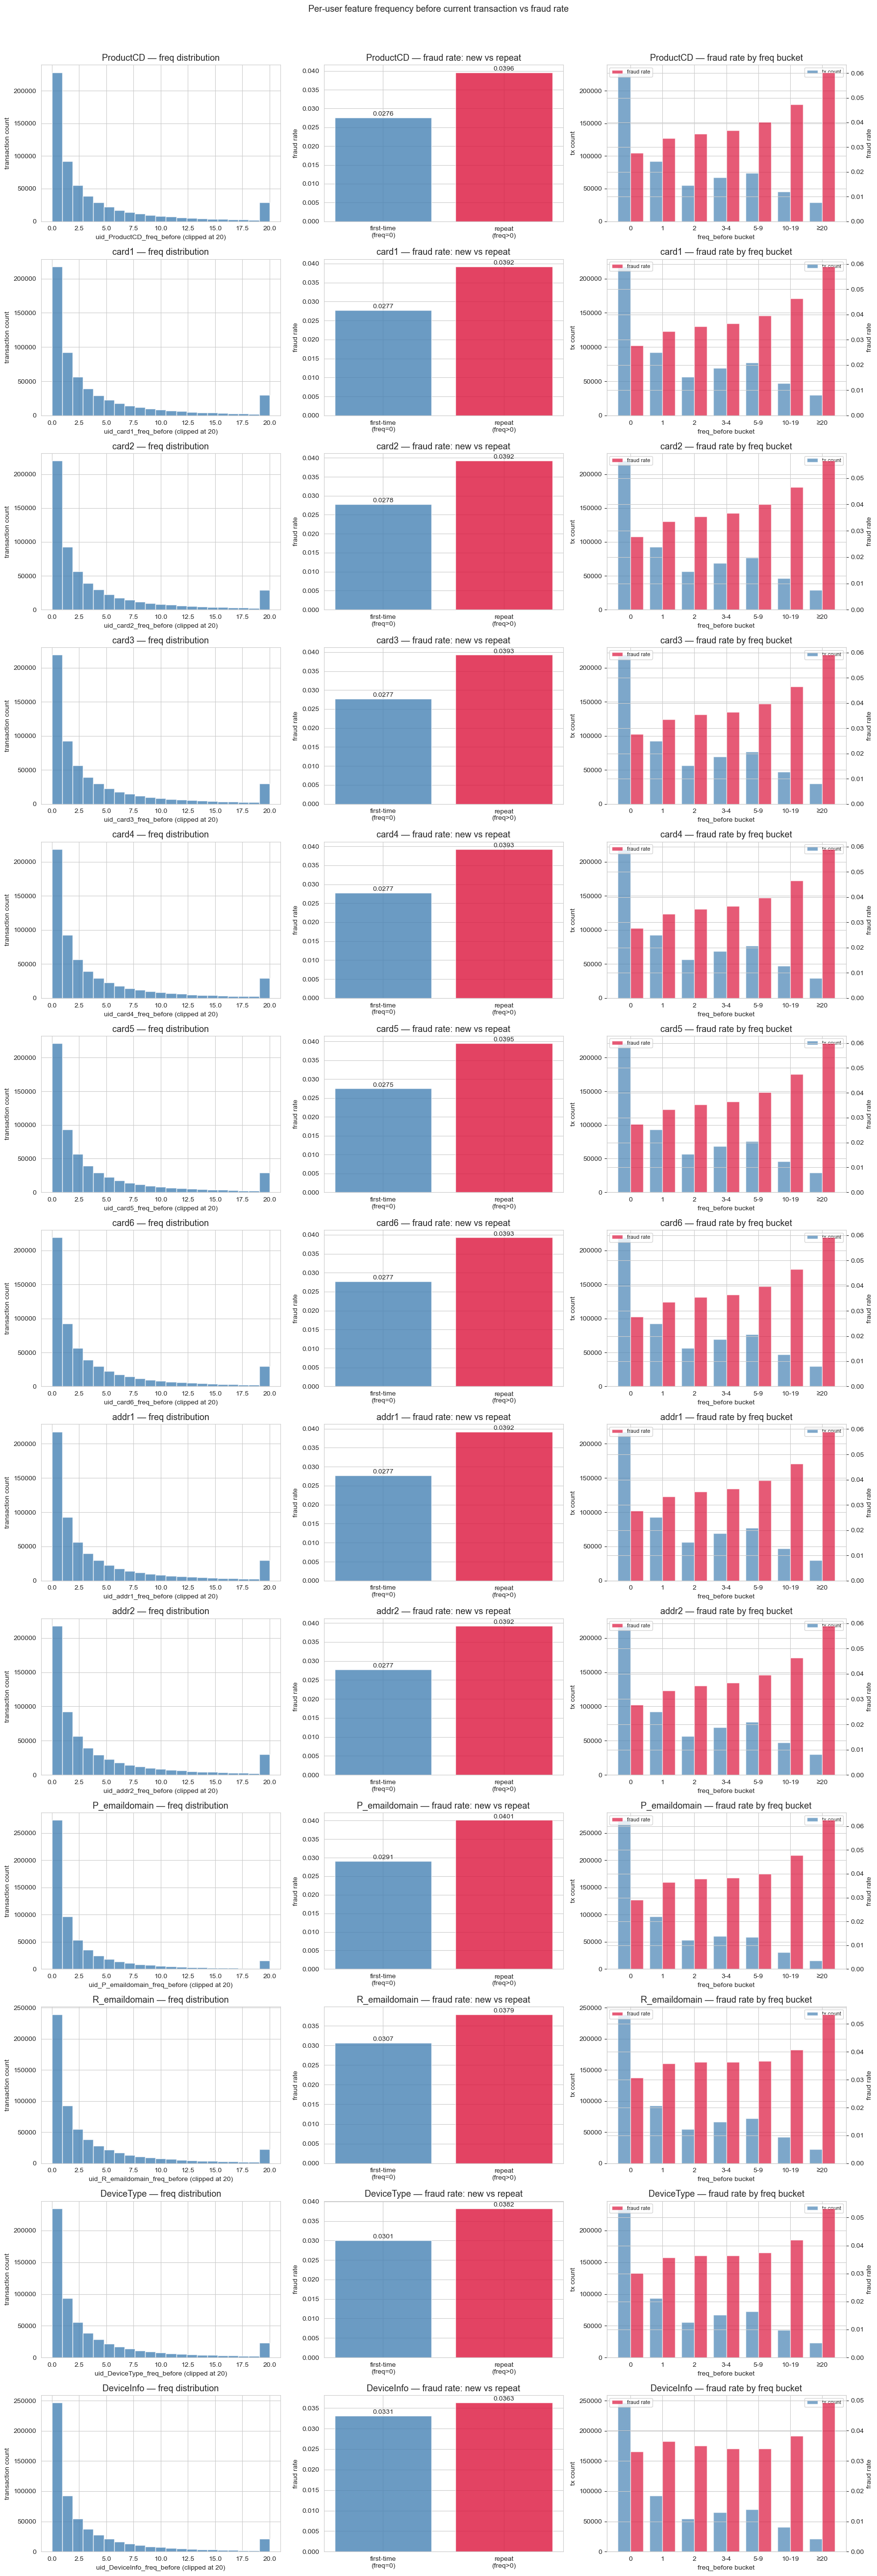

In [56]:
fig, axes = plt.subplots(13, 3, figsize=(18, 4 * len(check_cols)))

bins_edges = [0, 1, 2, 3, 5, 10, 20, 9999]
bin_labels = ['0', '1', '2', '3-4', '5-9', '10-19', '≥20']

for row, col in enumerate(check_cols):
    feat = f'uid_{col}_freq_before'
    s    = train_s[feat]

    # ── left: frequency distribution ─────────────────────────────────────────
    axes[row][0].hist(s.clip(upper=20), bins=21, color='steelblue', alpha=0.8, edgecolor='white')
    axes[row][0].set_xlabel(f'{feat} (clipped at 20)')
    axes[row][0].set_ylabel('transaction count')
    axes[row][0].set_title(f'{col} — freq distribution')

    # ── center: first-time vs repeat fraud rate ───────────────────────────────
    fr_new    = train_s.loc[s == 0, 'isFraud'].mean()
    fr_repeat = train_s.loc[s >  0, 'isFraud'].mean()
    bars = axes[row][1].bar(['first-time\n(freq=0)', 'repeat\n(freq>0)'],
                             [fr_new, fr_repeat],
                             color=['steelblue', 'crimson'], alpha=0.8)
    axes[row][1].set_ylabel('fraud rate')
    axes[row][1].set_title(f'{col} — fraud rate: new vs repeat')
    for bar, v in zip(bars, [fr_new, fr_repeat]):
        axes[row][1].text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                          f'{v:.4f}', ha='center', fontsize=10)

    # ── right: fraud rate by freq bucket ─────────────────────────────────────
    tmp = train_s[[feat, 'isFraud']].copy()
    tmp['bin'] = pd.cut(tmp[feat], bins=bins_edges, labels=bin_labels, right=False)
    bin_stats  = tmp.groupby('bin', observed=True)['isFraud'].agg(['mean','count']).reset_index()

    ax2 = axes[row][2].twinx()
    x   = range(len(bin_stats))
    axes[row][2].bar([i - 0.2 for i in x], bin_stats['count'], width=0.4,
                     color='steelblue', alpha=0.7, label='tx count')
    ax2.bar(         [i + 0.2 for i in x], bin_stats['mean'],  width=0.4,
                     color='crimson',   alpha=0.7, label='fraud rate')
    axes[row][2].set_xticks(x)
    axes[row][2].set_xticklabels(bin_labels)
    axes[row][2].set_xlabel('freq_before bucket')
    axes[row][2].set_ylabel('tx count')
    ax2.set_ylabel('fraud rate')
    axes[row][2].set_title(f'{col} — fraud rate by freq bucket')
    axes[row][2].legend(loc='upper right', fontsize=8)
    ax2.legend(loc='upper left', fontsize=8)

plt.suptitle('Per-user feature frequency before current transaction vs fraud rate', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Per-user value profile — ProductCD, P_emaildomain, R_emaildomain

For each user (`user_id1 = card1 + addr1 + D1_norm`), compute across the full dataset (train + test):
- **n_distinct**: how many distinct values of the column the user has used
- **mode_cnt**: how many times the user's most-frequent value appears  
- **is_mode**: whether the current transaction's value matches the user's mode

`observed=True` is required on groupby to avoid pandas expanding categorical dtype into a full cross-product (which gives cnt=0 everywhere).

In [59]:
# ── build user_id1 ────────────────────────────────────────────────────────────
for df in [train, val, test]:
    df['D1_norm']  = (df['TransactionDT'] // 86400).astype(int) - df['D1'].fillna(-1).astype(int)
    df['user_id1'] = (df['card1'].astype(str) + '_' +
                      df['addr1'].astype(str) + '_' +
                      df['D1_norm'].astype(str))

all_combined = pd.concat([train, val, test], ignore_index=True)
check_cols   = check_cols = ['ProductCD', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr2',
           'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo']


for col in check_cols:
    # ── 1. n_distinct: unique values per user ─────────────────────────────────
    n_distinct_map = all_combined.groupby('user_id1', observed=True)[col].nunique()
    train[f'n_distinct_{col}'] = train['user_id1'].map(n_distinct_map).fillna(1).astype(int)

    # ── 2. mode value + mode count — use .map() to avoid merge duplicate-col issue
    user_val_cnt = (all_combined.groupby(['user_id1', col], observed=True)
                                .size()
                                .reset_index(name='cnt'))
    best = (user_val_cnt.sort_values('cnt', ascending=False)
                        .drop_duplicates('user_id1')
                        .set_index('user_id1'))
    train[f'mode_{col}']     = train['user_id1'].map(best[col])
    train[f'mode_cnt_{col}'] = train['user_id1'].map(best['cnt']).fillna(0).astype(int)

    # ── 3. is_mode: current value matches user's modal value ──────────────────
    train[f'is_mode_{col}'] = (train[col] == train[f'mode_{col}']).astype(int)

new_feats = [f for col in check_cols
             for f in [f'n_distinct_{col}', f'mode_cnt_{col}', f'is_mode_{col}']]
print('Features added:', new_feats)
print(train[new_feats].describe().round(2))


Features added: ['n_distinct_ProductCD', 'mode_cnt_ProductCD', 'is_mode_ProductCD', 'n_distinct_card2', 'mode_cnt_card2', 'is_mode_card2', 'n_distinct_card3', 'mode_cnt_card3', 'is_mode_card3', 'n_distinct_card4', 'mode_cnt_card4', 'is_mode_card4', 'n_distinct_card5', 'mode_cnt_card5', 'is_mode_card5', 'n_distinct_card6', 'mode_cnt_card6', 'is_mode_card6', 'n_distinct_addr2', 'mode_cnt_addr2', 'is_mode_addr2', 'n_distinct_P_emaildomain', 'mode_cnt_P_emaildomain', 'is_mode_P_emaildomain', 'n_distinct_R_emaildomain', 'mode_cnt_R_emaildomain', 'is_mode_R_emaildomain', 'n_distinct_DeviceType', 'mode_cnt_DeviceType', 'is_mode_DeviceType', 'n_distinct_DeviceInfo', 'mode_cnt_DeviceInfo', 'is_mode_DeviceInfo']
       n_distinct_ProductCD  mode_cnt_ProductCD  is_mode_ProductCD  \
count             590540.00           590540.00          590540.00   
mean                   1.11               21.19               0.98   
std                    0.39              149.40               0.16   
min     

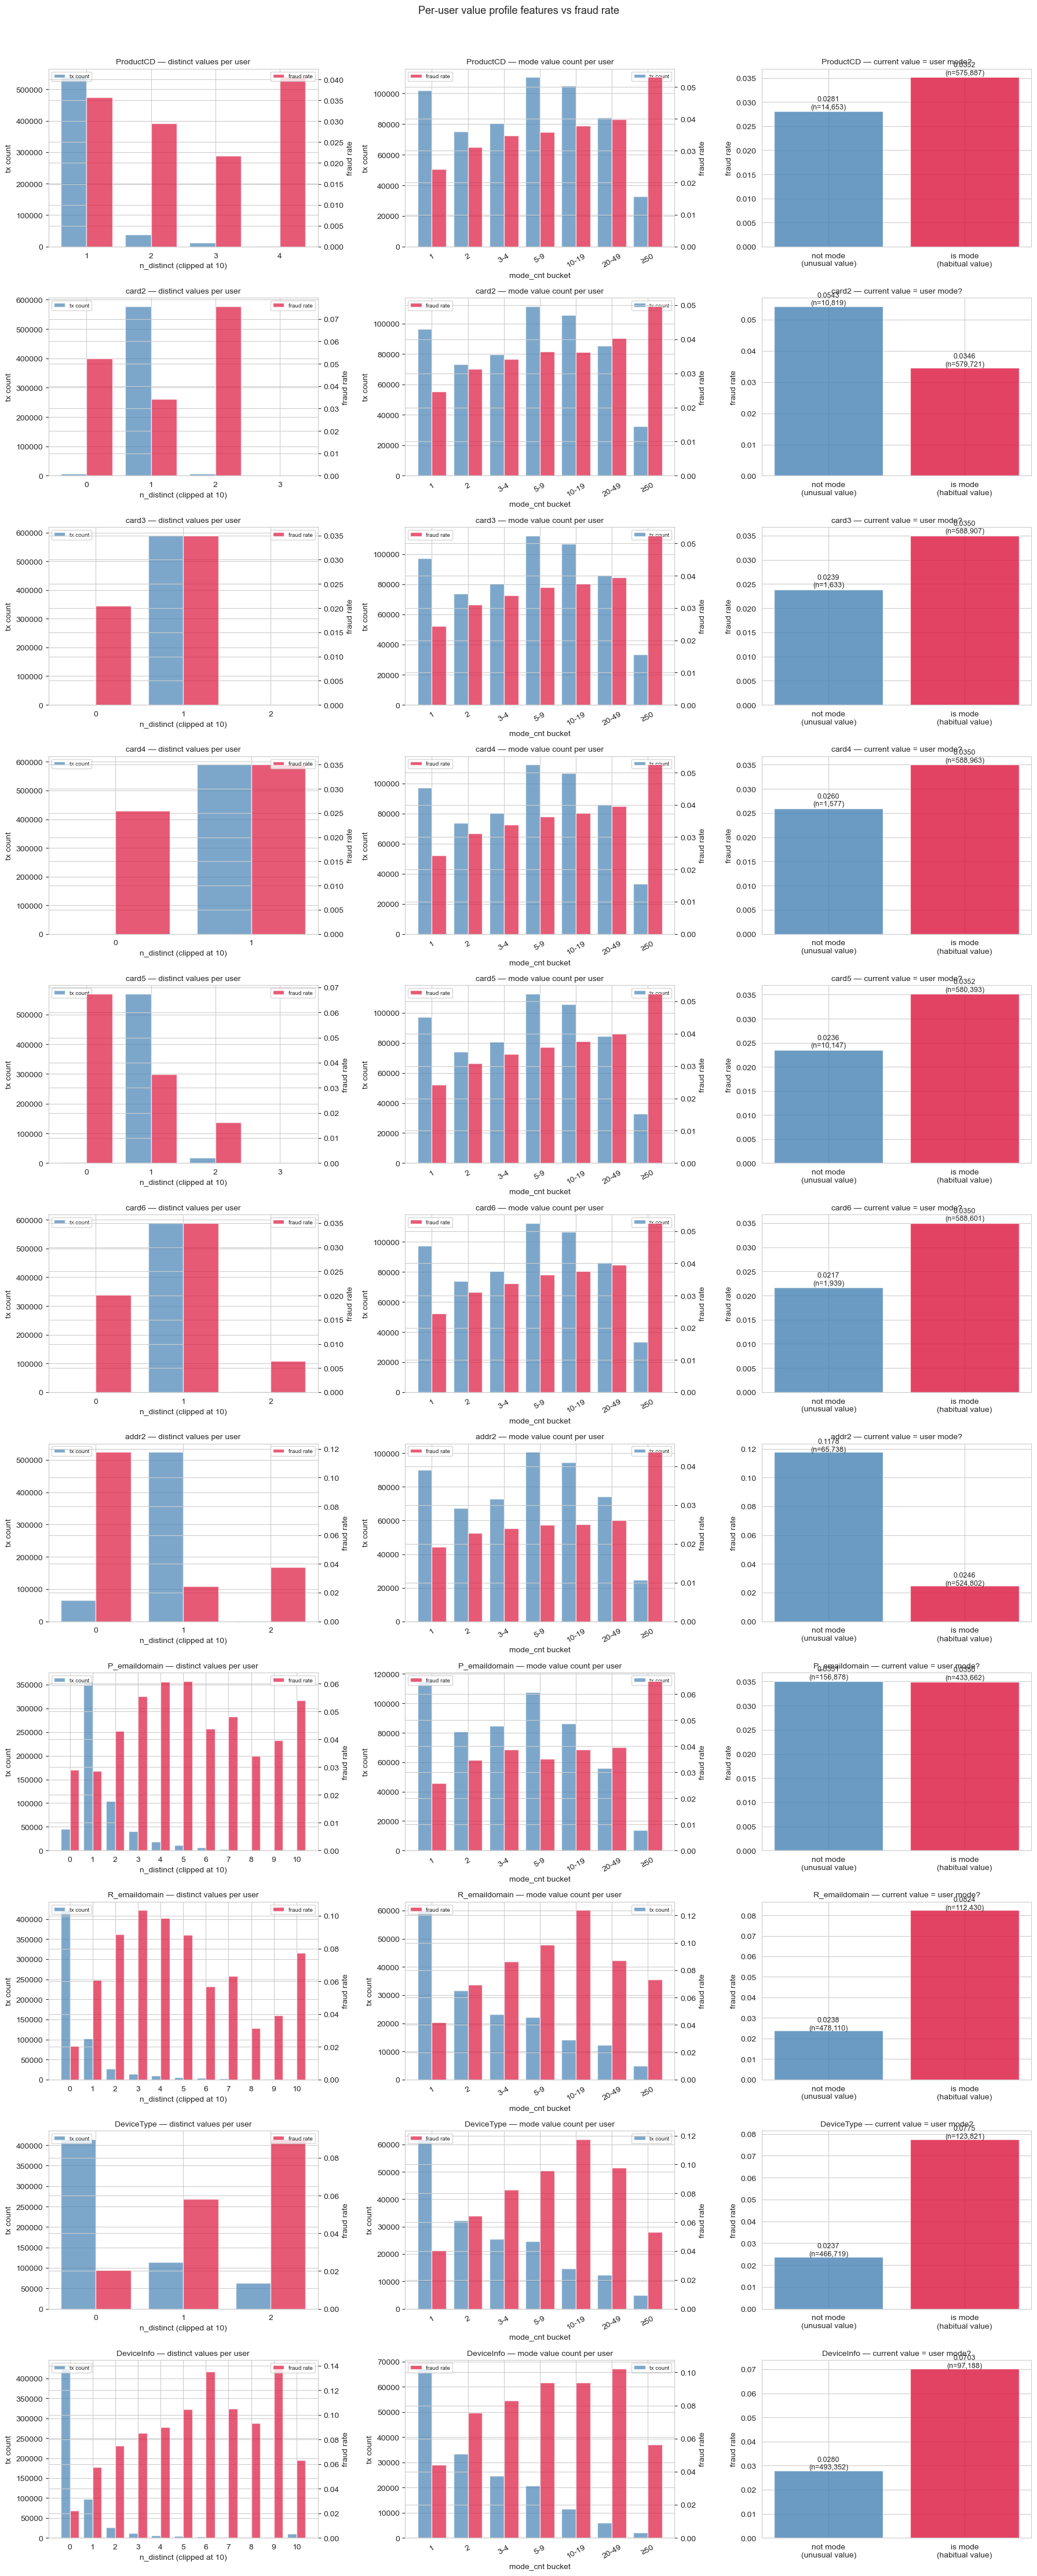

In [60]:
fig, axes = plt.subplots(11, 3, figsize=(18, 4 * len(check_cols)))


for row, col in enumerate(check_cols):
    # ── col 0: n_distinct vs fraud rate ──────────────────────────────────────
    tmp = train[[f'n_distinct_{col}', 'isFraud']].copy()
    tmp['bin'] = tmp[f'n_distinct_{col}'].clip(upper=10)   # most users use ≤10 distinct values
    bs = tmp.groupby('bin')['isFraud'].agg(['mean', 'count']).reset_index()

    ax2 = axes[row][0].twinx()
    x   = range(len(bs))
    axes[row][0].bar([i - 0.2 for i in x], bs['count'], width=0.4, color='steelblue', alpha=0.7, label='tx count')
    ax2.bar(         [i + 0.2 for i in x], bs['mean'],  width=0.4, color='crimson',   alpha=0.7, label='fraud rate')
    axes[row][0].set_xticks(x)
    axes[row][0].set_xticklabels(bs['bin'].astype(str))
    axes[row][0].set_title(f'{col} — distinct values per user', fontsize=10)
    axes[row][0].set_xlabel('n_distinct (clipped at 10)')
    axes[row][0].set_ylabel('tx count')
    ax2.set_ylabel('fraud rate')
    axes[row][0].legend(loc='upper left',  fontsize=7)
    ax2.legend(loc='upper right', fontsize=7)

    # ── col 1: mode_cnt vs fraud rate ────────────────────────────────────────
    tmp2 = train[[f'mode_cnt_{col}', 'isFraud']].copy()
    bins_e = [0, 1, 2, 3, 5, 10, 20, 50, tmp2[f'mode_cnt_{col}'].max() + 1]
    bin_l  = ['1', '2', '3-4', '5-9', '10-19', '20-49', '≥50']
    # fix: adjust bins to start from 1 since mode_cnt >= 1
    bins_e = [1, 2, 3, 5, 10, 20, 50, int(tmp2[f'mode_cnt_{col}'].max()) + 1]
    tmp2['bin'] = pd.cut(tmp2[f'mode_cnt_{col}'], bins=bins_e, labels=bin_l, right=False)
    bs2 = tmp2.groupby('bin', observed=True)['isFraud'].agg(['mean', 'count']).reset_index()

    ax2b = axes[row][1].twinx()
    x2   = range(len(bs2))
    axes[row][1].bar([i - 0.2 for i in x2], bs2['count'], width=0.4, color='steelblue', alpha=0.7, label='tx count')
    ax2b.bar(        [i + 0.2 for i in x2], bs2['mean'],  width=0.4, color='crimson',   alpha=0.7, label='fraud rate')
    axes[row][1].set_xticks(x2)
    axes[row][1].set_xticklabels(bin_l, rotation=30)
    axes[row][1].set_title(f'{col} — mode value count per user', fontsize=10)
    axes[row][1].set_xlabel('mode_cnt bucket')
    axes[row][1].set_ylabel('tx count')
    ax2b.set_ylabel('fraud rate')
    axes[row][1].legend(loc='upper right', fontsize=7)
    ax2b.legend(loc='upper left', fontsize=7)

    # ── col 2: is_mode vs fraud rate ─────────────────────────────────────────
    bs3 = train.groupby(f'is_mode_{col}')['isFraud'].agg(['mean', 'count']).reset_index()
    fr_vals  = bs3['mean'].values
    labels   = ['not mode\n(unusual value)', 'is mode\n(habitual value)']
    bars = axes[row][2].bar(labels, fr_vals, color=['steelblue', 'crimson'], alpha=0.8)
    axes[row][2].set_ylabel('fraud rate')
    axes[row][2].set_title(f'{col} — current value = user mode?', fontsize=10)
    for bar, v, cnt in zip(bars, fr_vals, bs3['count'].values):
        axes[row][2].text(bar.get_x() + bar.get_width()/2,
                          v + 0.0005, f'{v:.4f}\n(n={cnt:,})', ha='center', fontsize=9)

plt.suptitle('Per-user value profile features vs fraud rate', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()